# PRT661 – Housing Affordability Forecasting System
## Assessment 2

**Group:** Dan1-Theme2 · **Theme 2 — Predictive Analytics and Forecasting**

**Steps:**
1. Setup & data loading
2. Reusable EDA functions
3. **EDA round 1** on the raw data → this is what tells us *how* to clean it
4. Cleaning, outlier treatment, feature engineering & merging — each step justified by something Round 1 found
5. **EDA round 2** — the exact same EDA, called again on the cleaned/merged data, this time against the target — this is what tells us *which features actually matter*
6. Modeling: Linear Regression, Random Forest, XGBoost, trained and compared on actual sale price (AUD)
7. Feature importance, model selection, and a short write-up of findings


## Project Setup — Imports & Configuration

In [52]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 19
np.random.seed(RANDOM_STATE)

In [53]:
# Data directories
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = DATA_DIR / "output"

for d in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROPERTIES_PATH = PROCESSED_DIR / "properties.csv"
POPULATION_PATH = PROCESSED_DIR / "population.csv"
HOUSEHOLD_INCOME_PATH = PROCESSED_DIR / "household_income.csv"

# Darwin CBD reference coordinates, used for the "distance from CBD" feature
DARWIN_CBD_LAT, DARWIN_CBD_LON = -12.4634, 130.8456

## 1. Load Data
Loads the three raw/processed CSVs and prints a quick check (shape, dtypes, missing
values) for each — this doubles as the Veracity check referenced in Assessment 2, Section 3.2
(5 Vs). We keep an untouched `_processed` copy of every dataframe and only ever mutate a
`.copy()` of it, so we can always go back and compare "before" vs "after" cleaning honestly.

In [54]:
def load_csv(path, name):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find file at {path}.")
    df = pd.read_csv(path)
    print(f"Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df

properties_processed = load_csv(PROPERTIES_PATH, "Properties Dataset")
population_processed = load_csv(POPULATION_PATH, "Population Dataset")
household_income_processed = load_csv(HOUSEHOLD_INCOME_PATH, "Household and Income Dataset")

Loaded Properties Dataset: 15,423 rows x 18 columns
Loaded Population Dataset: 44 rows x 26 columns
Loaded Household and Income Dataset: 305 rows x 23 columns


In [55]:
def check_data(df, name):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")
    display(df.head(2))

check_data(properties_processed, "Properties Dataset")
check_data(population_processed, "Population Dataset")
check_data(household_income_processed, "Household and Income Dataset")


Properties Dataset
property_id            int64
address                  str
url                      str
status                   str
sold_date                str
sold_date_iso            str
price_text               str
price_numeric        float64
price_undisclosed       bool
beds                   int64
baths                  int64
cars                   int64
land_area_m2             str
latitude             float64
longitude            float64
agent_name               str
agency_name              str
suburb                   str
dtype: object

Missing values:
agent_name       13273
agency_name      13273
land_area_m2      5800
price_text        5088
price_numeric     5088
sold_date          250
sold_date_iso      250
latitude           226
longitude          226
dtype: int64


,property_id,address,url,status,sold_date,sold_date_iso,price_text,price_numeric,price_undisclosed,beds,baths,cars,land_area_m2,latitude,longitude,agent_name,agency_name,suburb
0,11245030,"22 Caledonian Street, Anula NT 812",https://www.homely.com.au/homes/22-caledonian-...,Sold,15 Aug 2024,2024-08-15T00:00:00+00:00,"$540,000",540000.0,False,3,1,2,985m²,-12.393042,130.887771,Ella Carling,Real Estate Central,anula-nt-0812
1,11057061,"52 Wandie Crescent, Anula NT 812",https://www.homely.com.au/homes/52-wandie-cres...,Sold,4 Jul 2024,2024-07-04T00:00:00+00:00,"$560,000",560000.0,False,3,1,3,743m²,-12.394495,130.893049,Simon Watts,Real Estate Central,anula-nt-0812



Population Dataset
SA2_name      str
2001        int64
2002        int64
2003        int64
2004        int64
2005        int64
2006        int64
2007        int64
2008        int64
2009        int64
2010        int64
2011        int64
2012        int64
2013        int64
2014        int64
2015        int64
2016        int64
2017        int64
2018        int64
2019        int64
2020        int64
2021        int64
2022        int64
2023        int64
2024        int64
2025        int64
dtype: object

No missing values.


,SA2_name,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Darwin Airport,23,22,21,21,21,20,21,15,17,15,469,469,466,18,17,16,17,18,18,19,20,20,20,20,20
1,Darwin City,2140,2248,2320,2429,2661,2798,3052,3664,4352,4841,5053,5412,5862,6288,7056,7591,7917,7786,7633,7612,7578,7722,8077,8273,8597



Household and Income Dataset
SAL_CODE_2021                                  str
SA2_name                                       str
census_year                                  int64
area_sqkm                                  float64
total_population                             int64
population_density_per_sqkm                float64
median_age_persons                           int64
median_personal_income_weekly_aud            int64
median_family_income_weekly_aud              int64
median_household_income_weekly_aud           int64
median_mortgage_repayment_monthly_aud        int64
median_rent_weekly_aud                       int64
average_persons_per_bedroom                float64
average_household_size                     float64
total_households_income_table                int64
known_income_households                      int64
pct_households_income_below_1000_weekly    float64
pct_households_income_2000plus_weekly      float64
one_person_households                        int64
t

,SAL_CODE_2021,SA2_name,census_year,area_sqkm,total_population,population_density_per_sqkm,median_age_persons,median_personal_income_weekly_aud,median_family_income_weekly_aud,median_household_income_weekly_aud,median_mortgage_repayment_monthly_aud,median_rent_weekly_aud,average_persons_per_bedroom,average_household_size,total_households_income_table,known_income_households,pct_households_income_below_1000_weekly,pct_households_income_2000plus_weekly,one_person_households,total_households_size_table,pct_one_person_households,in_realestate_sample_suburbs,source
0,SAL70003,Alawa,2021,1.2399,2078,1675.941608,35,915,2186,2083,1777,340,0.9,2.8,679,612,0.245098,0.513072,118,679,0.173785,True,ABS 2021 Census General Community Profile Data...
1,SAL70014,Anula,2021,1.3178,2385,1809.834573,37,1034,2492,2269,2000,400,0.9,2.9,760,687,0.183406,0.567686,125,760,0.164474,True,ABS 2021 Census General Community Profile Data...


## 2. Reusable EDA Functions
We define a small set of EDA functions **once**, here, before any cleaning happens. Because every function takes a dataframe and a `name` (and figures out which columns to look at on its own, rather than hard-coding column names), the
exact same functions can be called:

- **now**, on the raw data, to decide *how* to clean it, and
- **again later** (Section 7), on the cleaned/merged modelling table, to decide *which
  features actually matter* for predicting price.

`run_eda()` ties them together and returns a dict of the key numbers (missing %, skew,
correlation with the target) so two calls — "before" and "after" — can be compared directly
instead of just eyeballing two sets of plots.

In [56]:
def eda_overview(df, name):
    """Shape, duplicate rows, and missing-value % — the first three questions to ask
    of any dataframe, raw or cleaned."""
    print(f"\n{'='*70}\n{name} \u2014 Structural Overview\n{'='*70}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    dup = int(df.duplicated().sum())
    print(f"Duplicate rows: {dup:,}")
    missing = df.isna().mean().sort_values(ascending=False) * 100
    missing = missing[missing > 0]
    if len(missing):
        print("\nMissing %% by column:")
        print(missing.round(1).to_string())
    else:
        print("\nNo missing values.")
    return {"shape": df.shape, "duplicates": dup, "missing_pct": missing}

In [57]:
def eda_numeric(df, name, cols=None, max_cols=4):
    """Descriptive stats + distribution histograms for numeric columns. Skew is
    returned so we can later decide whether a log transform is worth it."""
    cols = cols if cols is not None else df.select_dtypes(include=np.number).columns.tolist()
    cols = [c for c in cols if c in df.columns and df[c].nunique(dropna=True) > 1]
    if not cols:
        print(f"No numeric columns to plot for {name}.")
        return {"skew": pd.Series(dtype=float)}

    print(f"\nNumeric summary \u2014 {name}")
    display(df[cols].describe().T)

    n_rows = int(np.ceil(len(cols) / max_cols))
    fig, axes = plt.subplots(n_rows, max_cols, figsize=(4.5 * max_cols, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax)
        ax.set_title(col, fontsize=10)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(f"Distributions \u2014 {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    skew = df[cols].skew().sort_values(key=abs, ascending=False)
    return {"skew": skew}

In [58]:
def eda_outliers(df, name, cols=None, max_cols=4):
    """Boxplots for numeric columns \u2014 the visual basis for the IQR outlier
    treatment in Section 5."""
    cols = cols if cols is not None else df.select_dtypes(include=np.number).columns.tolist()
    cols = [c for c in cols if c in df.columns and df[c].nunique(dropna=True) > 1]
    if not cols:
        return
    n_rows = int(np.ceil(len(cols) / max_cols))
    fig, axes = plt.subplots(n_rows, max_cols, figsize=(4.5 * max_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(f"Outlier Detection \u2014 {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [59]:
def eda_categorical(df, name, cols=None, top_n=12, max_cols=3):
    """Bar charts of the top categories for low/medium-cardinality text columns.
    High-cardinality columns (like a free-text address) or single-value columns
    are skipped automatically \u2014 they're not useful to plot."""
    cols = cols if cols is not None else df.select_dtypes(include=["object", "category"]).columns.tolist()
    cols = [c for c in cols if c in df.columns and 1 < df[c].nunique(dropna=True) <= 60]
    if not cols:
        print(f"No categorical columns with a plottable cardinality for {name}.")
        return
    n_rows = int(np.ceil(len(cols) / max_cols))
    fig, axes = plt.subplots(n_rows, max_cols, figsize=(5.5 * max_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        vc = df[col].value_counts().head(top_n)
        sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax)
        ax.set_title(col, fontsize=10)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(f"Top Categories \u2014 {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [60]:
def eda_correlation(df, name, target=None):
    """Correlation heatmap for numeric columns, plus \u2014 if `target` is given and
    present \u2014 a ranked bar chart of every feature's correlation with it. This is
    the plot that turns into a feature-selection decision in Section 7."""
    num = df.select_dtypes(include=np.number)
    num = num.loc[:, num.nunique(dropna=True) > 1]
    if num.shape[1] < 2:
        print(f"Not enough numeric columns to correlate for {name}.")
        return {"corr": None, "target_corr": None}

    corr = num.corr(numeric_only=True)
    plt.figure(figsize=(0.55 * len(corr.columns) + 3, 0.5 * len(corr.columns) + 2))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=len(corr.columns) <= 14, fmt=".2f")
    plt.title(f"Correlation Matrix \u2014 {name}")
    plt.tight_layout()
    plt.show()

    target_corr = None
    if target and target in corr.columns:
        target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
        plt.figure(figsize=(6, 0.35 * len(target_corr) + 1))
        sns.barplot(x=target_corr.values, y=target_corr.index, palette="vlag")
        plt.title(f"Correlation with {target} \u2014 {name}")
        plt.axvline(0, color="black", lw=0.8)
        plt.tight_layout()
        plt.show()
        print(f"\nStrongest correlations with {target}:")
        print(target_corr.round(3).to_string())

    return {"corr": corr, "target_corr": target_corr}

In [61]:
def run_eda(df, name, target=None, numeric_cols=None, categorical_cols=None):
    """
    Runs the full EDA suite in one call: structural overview -> numeric
    distributions -> outlier boxplots -> categorical breakdowns -> correlation
    (against `target` if supplied).

    Safe to call MORE THAN ONCE on the same underlying data \u2014 it inspects
    whichever columns actually exist on `df` at call time rather than hard-coding
    names, so it works equally well:
      1. on the raw, just-loaded dataframe (no target yet \u2014 we don't have a
         clean price column at that point), and
      2. again after cleaning / feature engineering / merging, this time with
         target="price_numeric", to see what actually drives price.

    Returns a dict of the key stats so two calls can be compared directly, e.g.
    `eda_before["numeric"]["skew"]` vs `eda_after["numeric"]["skew"]`.
    """
    summary = {}
    summary["overview"] = eda_overview(df, name)
    summary["numeric"] = eda_numeric(df, name, cols=numeric_cols)
    eda_outliers(df, name, cols=numeric_cols)
    eda_categorical(df, name, cols=categorical_cols)
    summary["correlation"] = eda_correlation(df, name, target=target)
    return summary

## 3. EDA — Round 1 (Raw Data)
Before touching anything, we run the toolkit on the raw data. This is what decides the cleaning
plan in Section 4.


Properties (raw) — Structural Overview
Shape: 15,423 rows x 18 columns
Duplicate rows: 0

Missing %% by column:
agency_name      86.1
agent_name       86.1
land_area_m2     37.6
price_text       33.0
price_numeric    33.0
sold_date         1.6
sold_date_iso     1.6
longitude         1.5
latitude          1.5

Numeric summary — Properties (raw)


,count,mean,std,min,25%,50%,75%,max
price_numeric,10335.0,557829.517465,326623.633439,1.000000,400000.000000,520000.000000,660000.000000,1.320000e+07
beds,15423.0,2.984439,1.331030,0.000000,2.000000,3.000000,4.000000,3.000000e+01
baths,15423.0,1.687350,0.815426,0.000000,1.000000,2.000000,2.000000,2.000000e+01
cars,15423.0,2.223951,1.603282,0.000000,2.000000,2.000000,2.000000,2.500000e+01
latitude,15197.0,-12.214370,3.200318,-41.364925,-12.496970,-12.456446,-12.391862,5.478307e+01
longitude,15197.0,130.575663,7.210794,-121.296743,130.848881,130.894385,130.986664,1.535698e+02


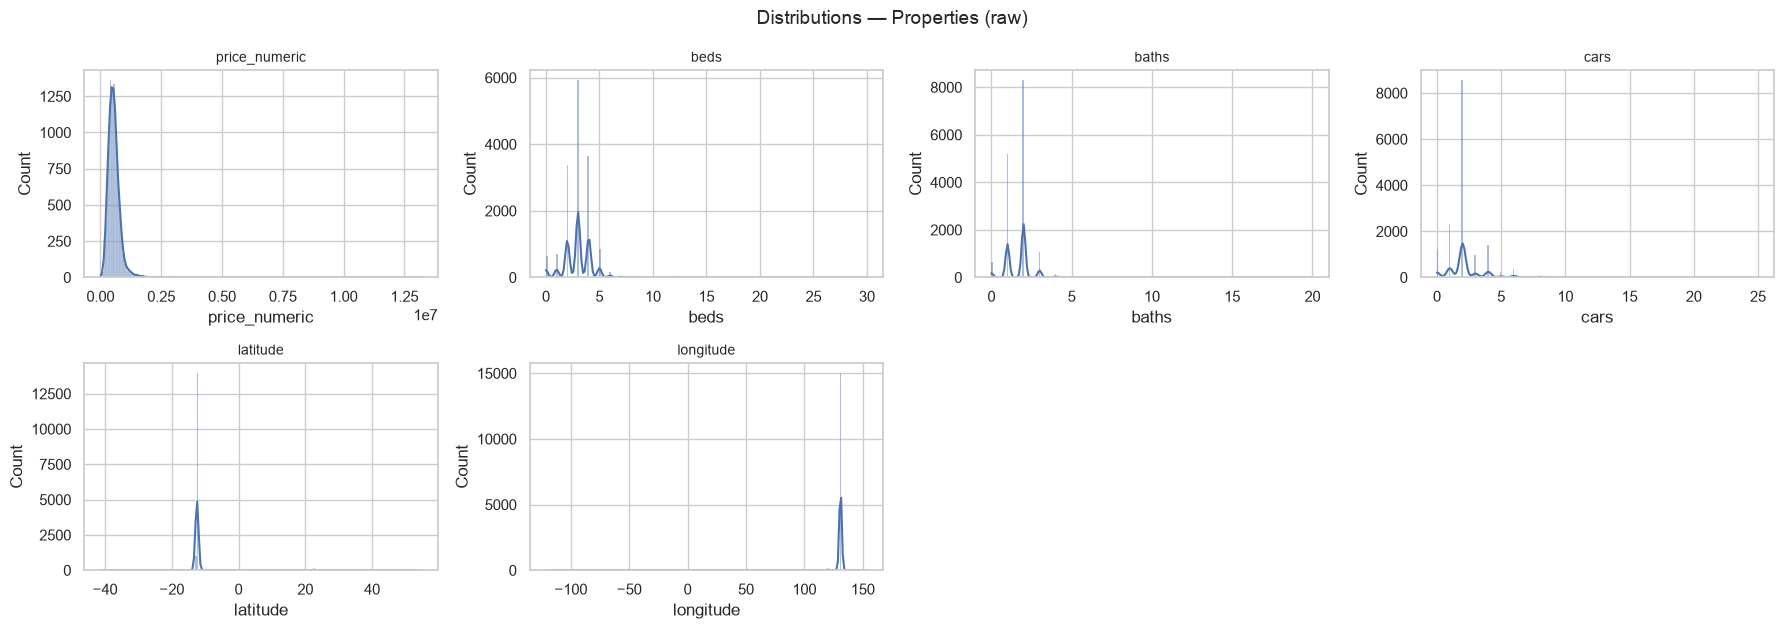

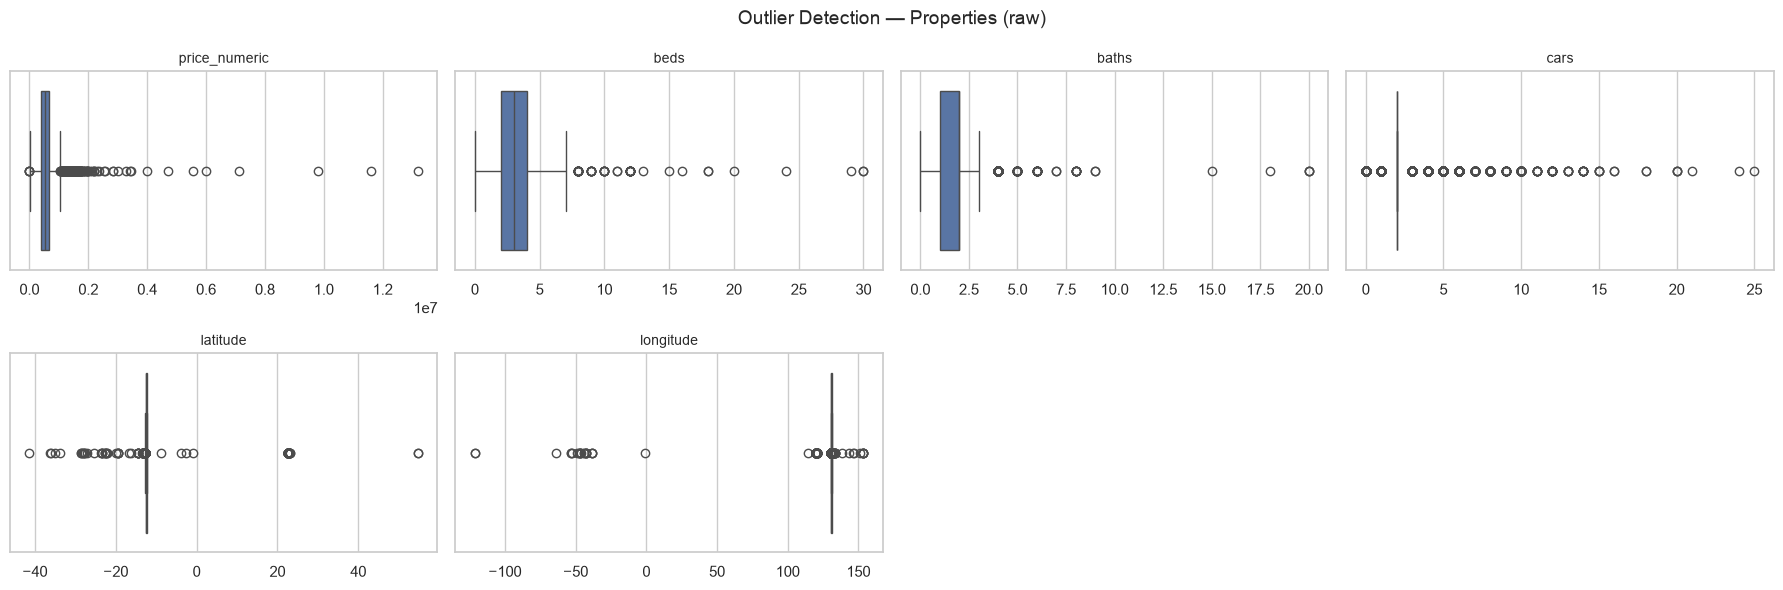

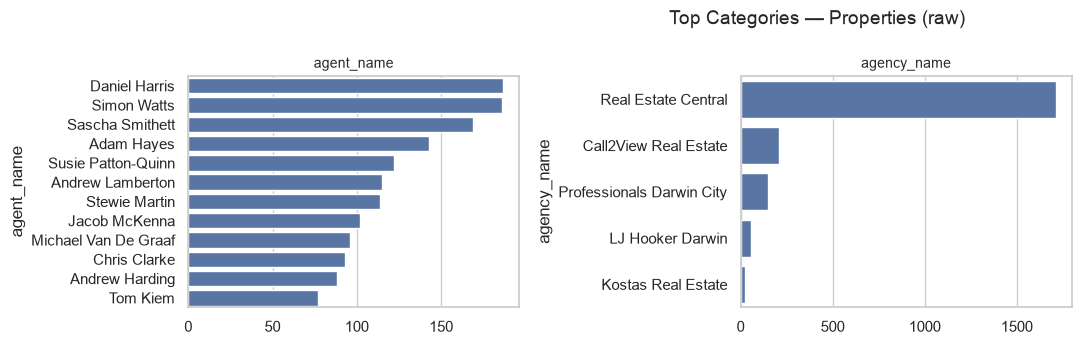

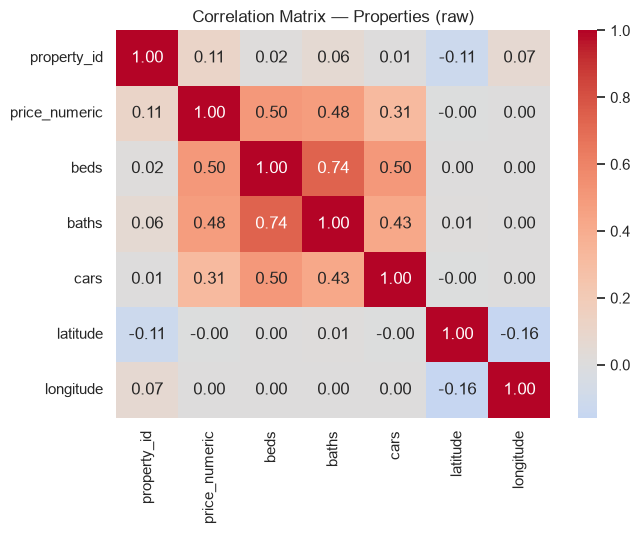

In [62]:
eda_properties_raw = run_eda(
    properties_processed, "Properties (raw)",
    numeric_cols=["price_numeric", "beds", "baths", "cars", "latitude", "longitude"],
)


Population (raw, wide format) — Structural Overview
Shape: 44 rows x 26 columns
Duplicate rows: 0

No missing values.

Numeric summary — Population (raw, wide format)


,count,mean,std,min,25%,50%,75%,max
2001,44.0,2460.909091,1561.367630,0.0,1665.25,2639.5,3323.75,6116.0
2002,44.0,2469.977273,1540.936419,0.0,1848.00,2625.5,3285.75,6172.0
2003,44.0,2464.386364,1521.683740,0.0,1906.25,2581.5,3252.75,6184.0
2004,44.0,2482.068182,1512.485501,0.0,1920.75,2571.0,3260.25,6218.0
2005,44.0,2531.545455,1518.118396,0.0,1947.50,2680.0,3400.75,6369.0
2006,44.0,2578.659091,1527.484160,0.0,1964.25,2744.0,3499.50,6483.0
2007,44.0,2657.613636,1565.037977,0.0,1999.50,2836.5,3529.25,6864.0
2008,44.0,2754.772727,1608.745371,0.0,2180.50,2935.5,3604.00,7265.0
2009,44.0,2848.068182,1647.681393,0.0,2195.75,3027.0,3576.00,7663.0
2010,44.0,2905.204545,1683.972181,0.0,2200.50,3084.0,3660.25,8060.0


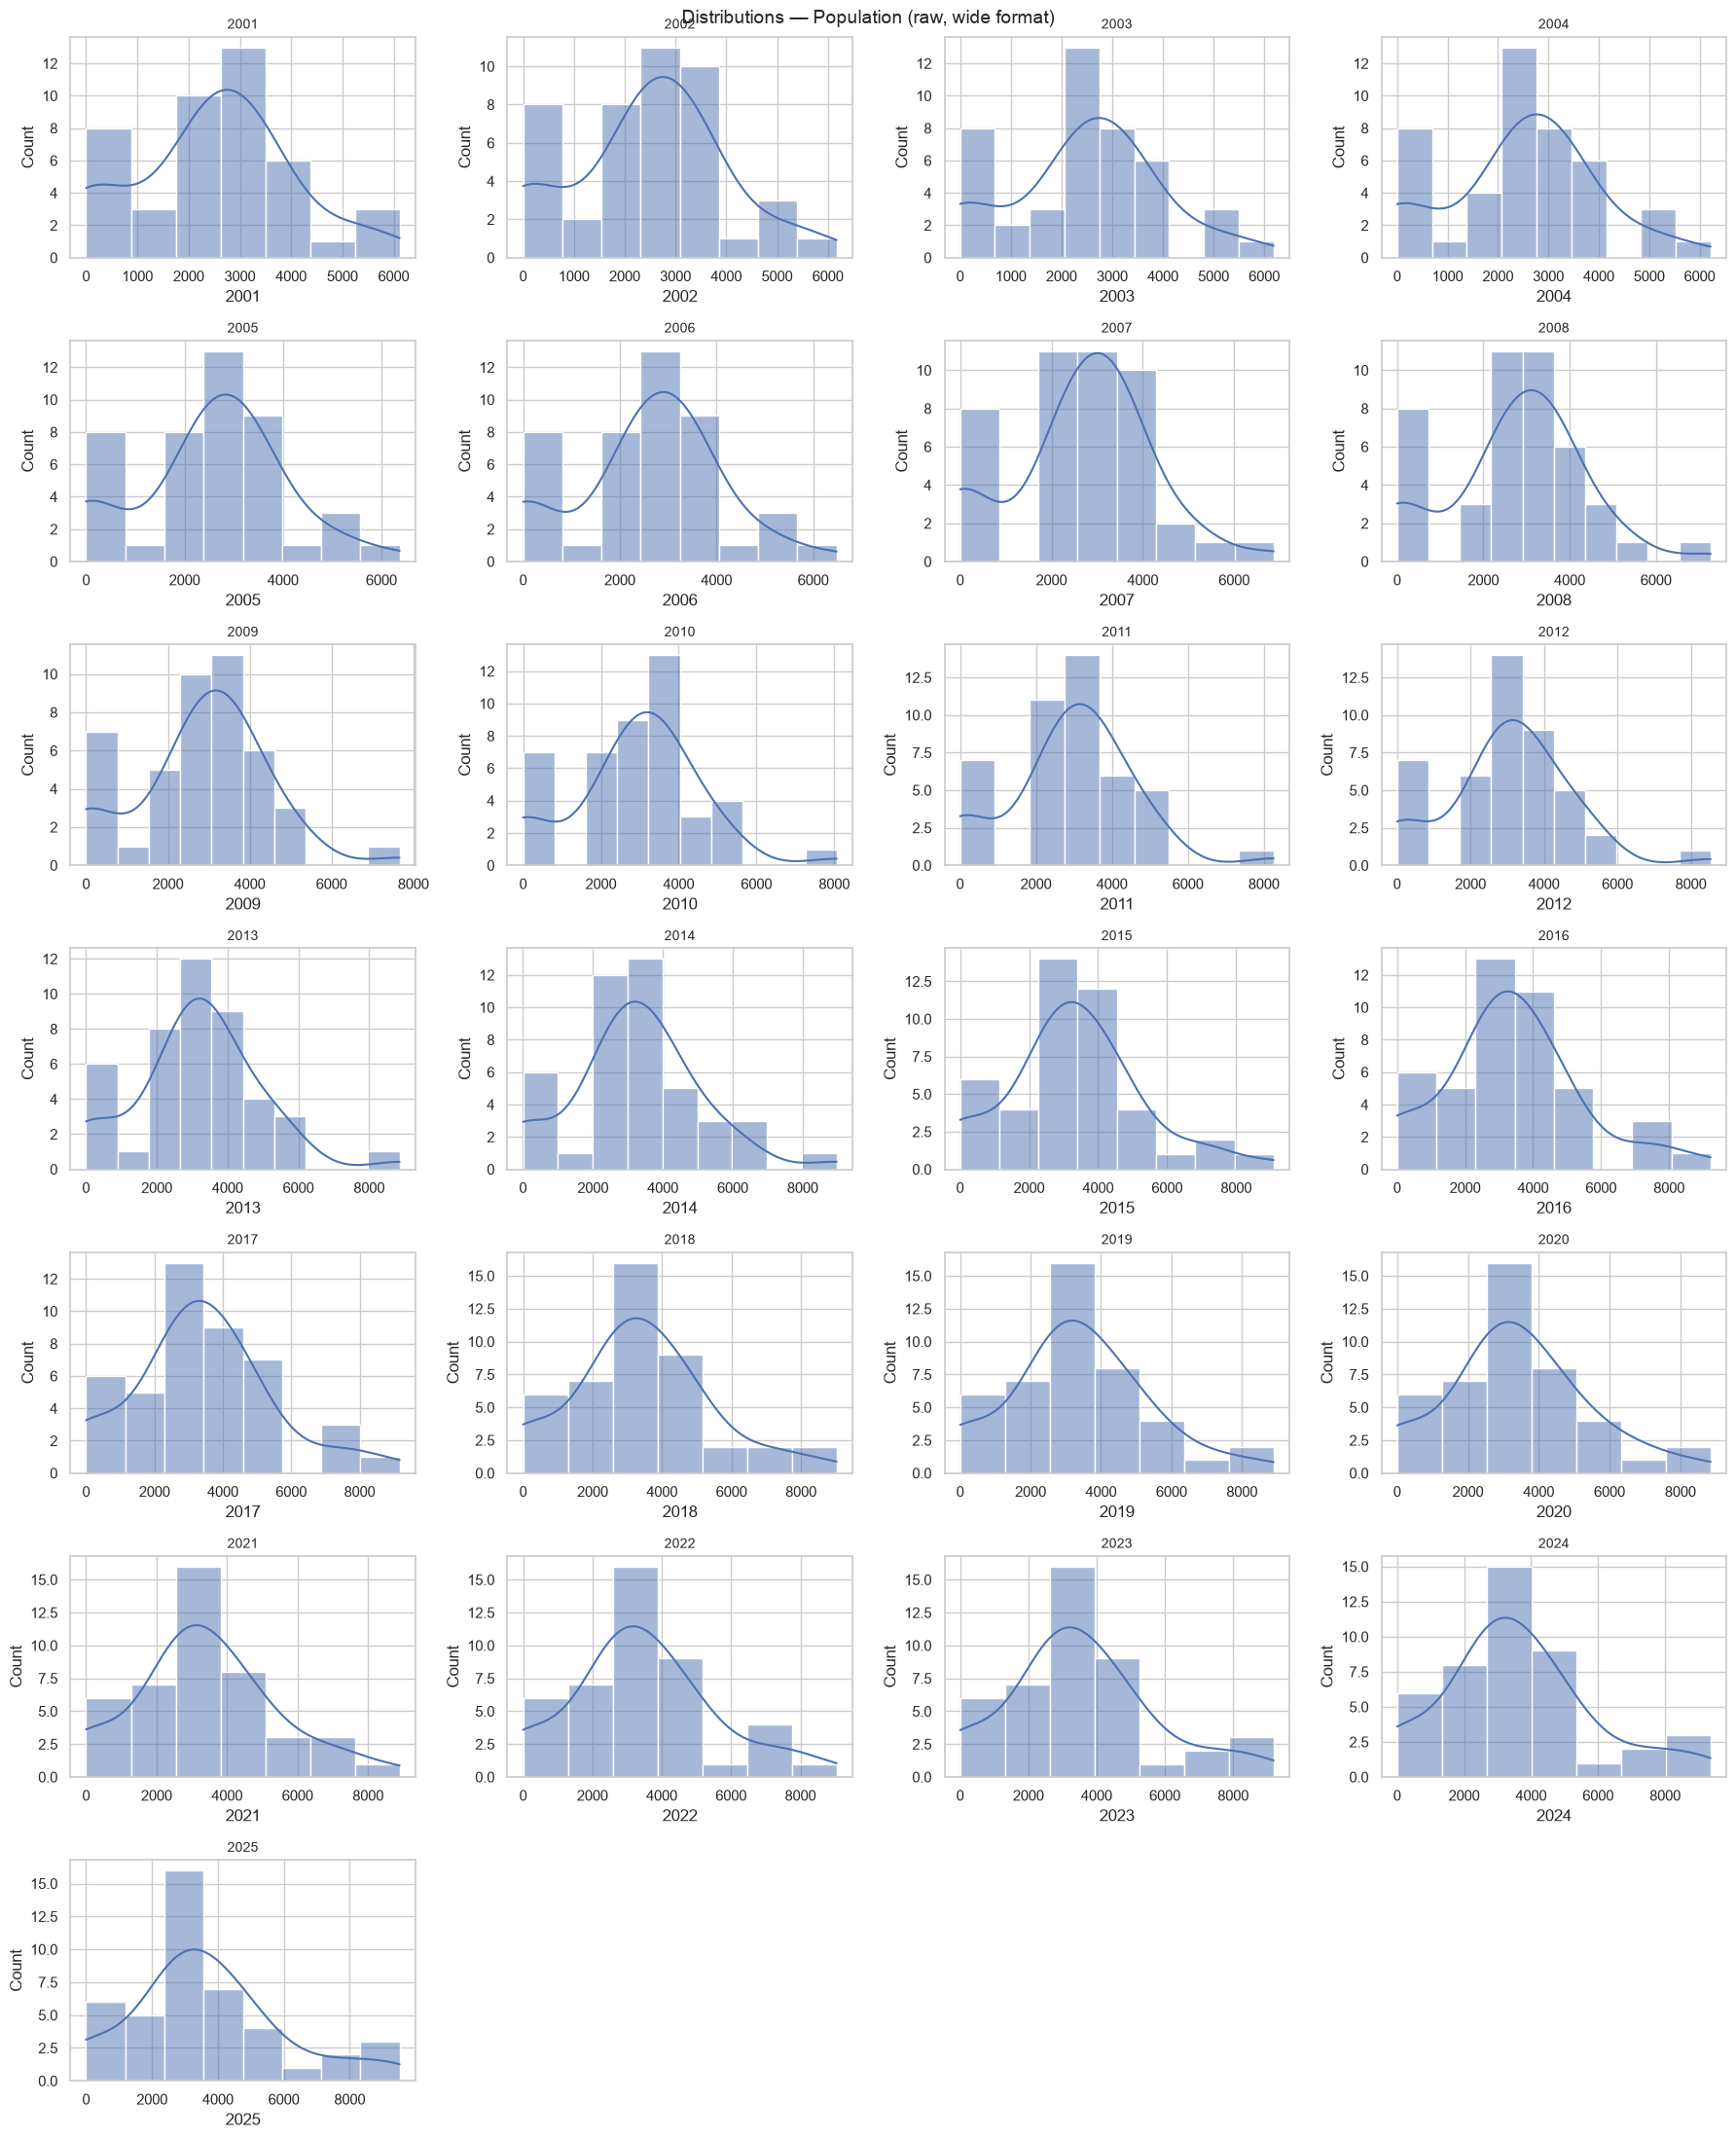

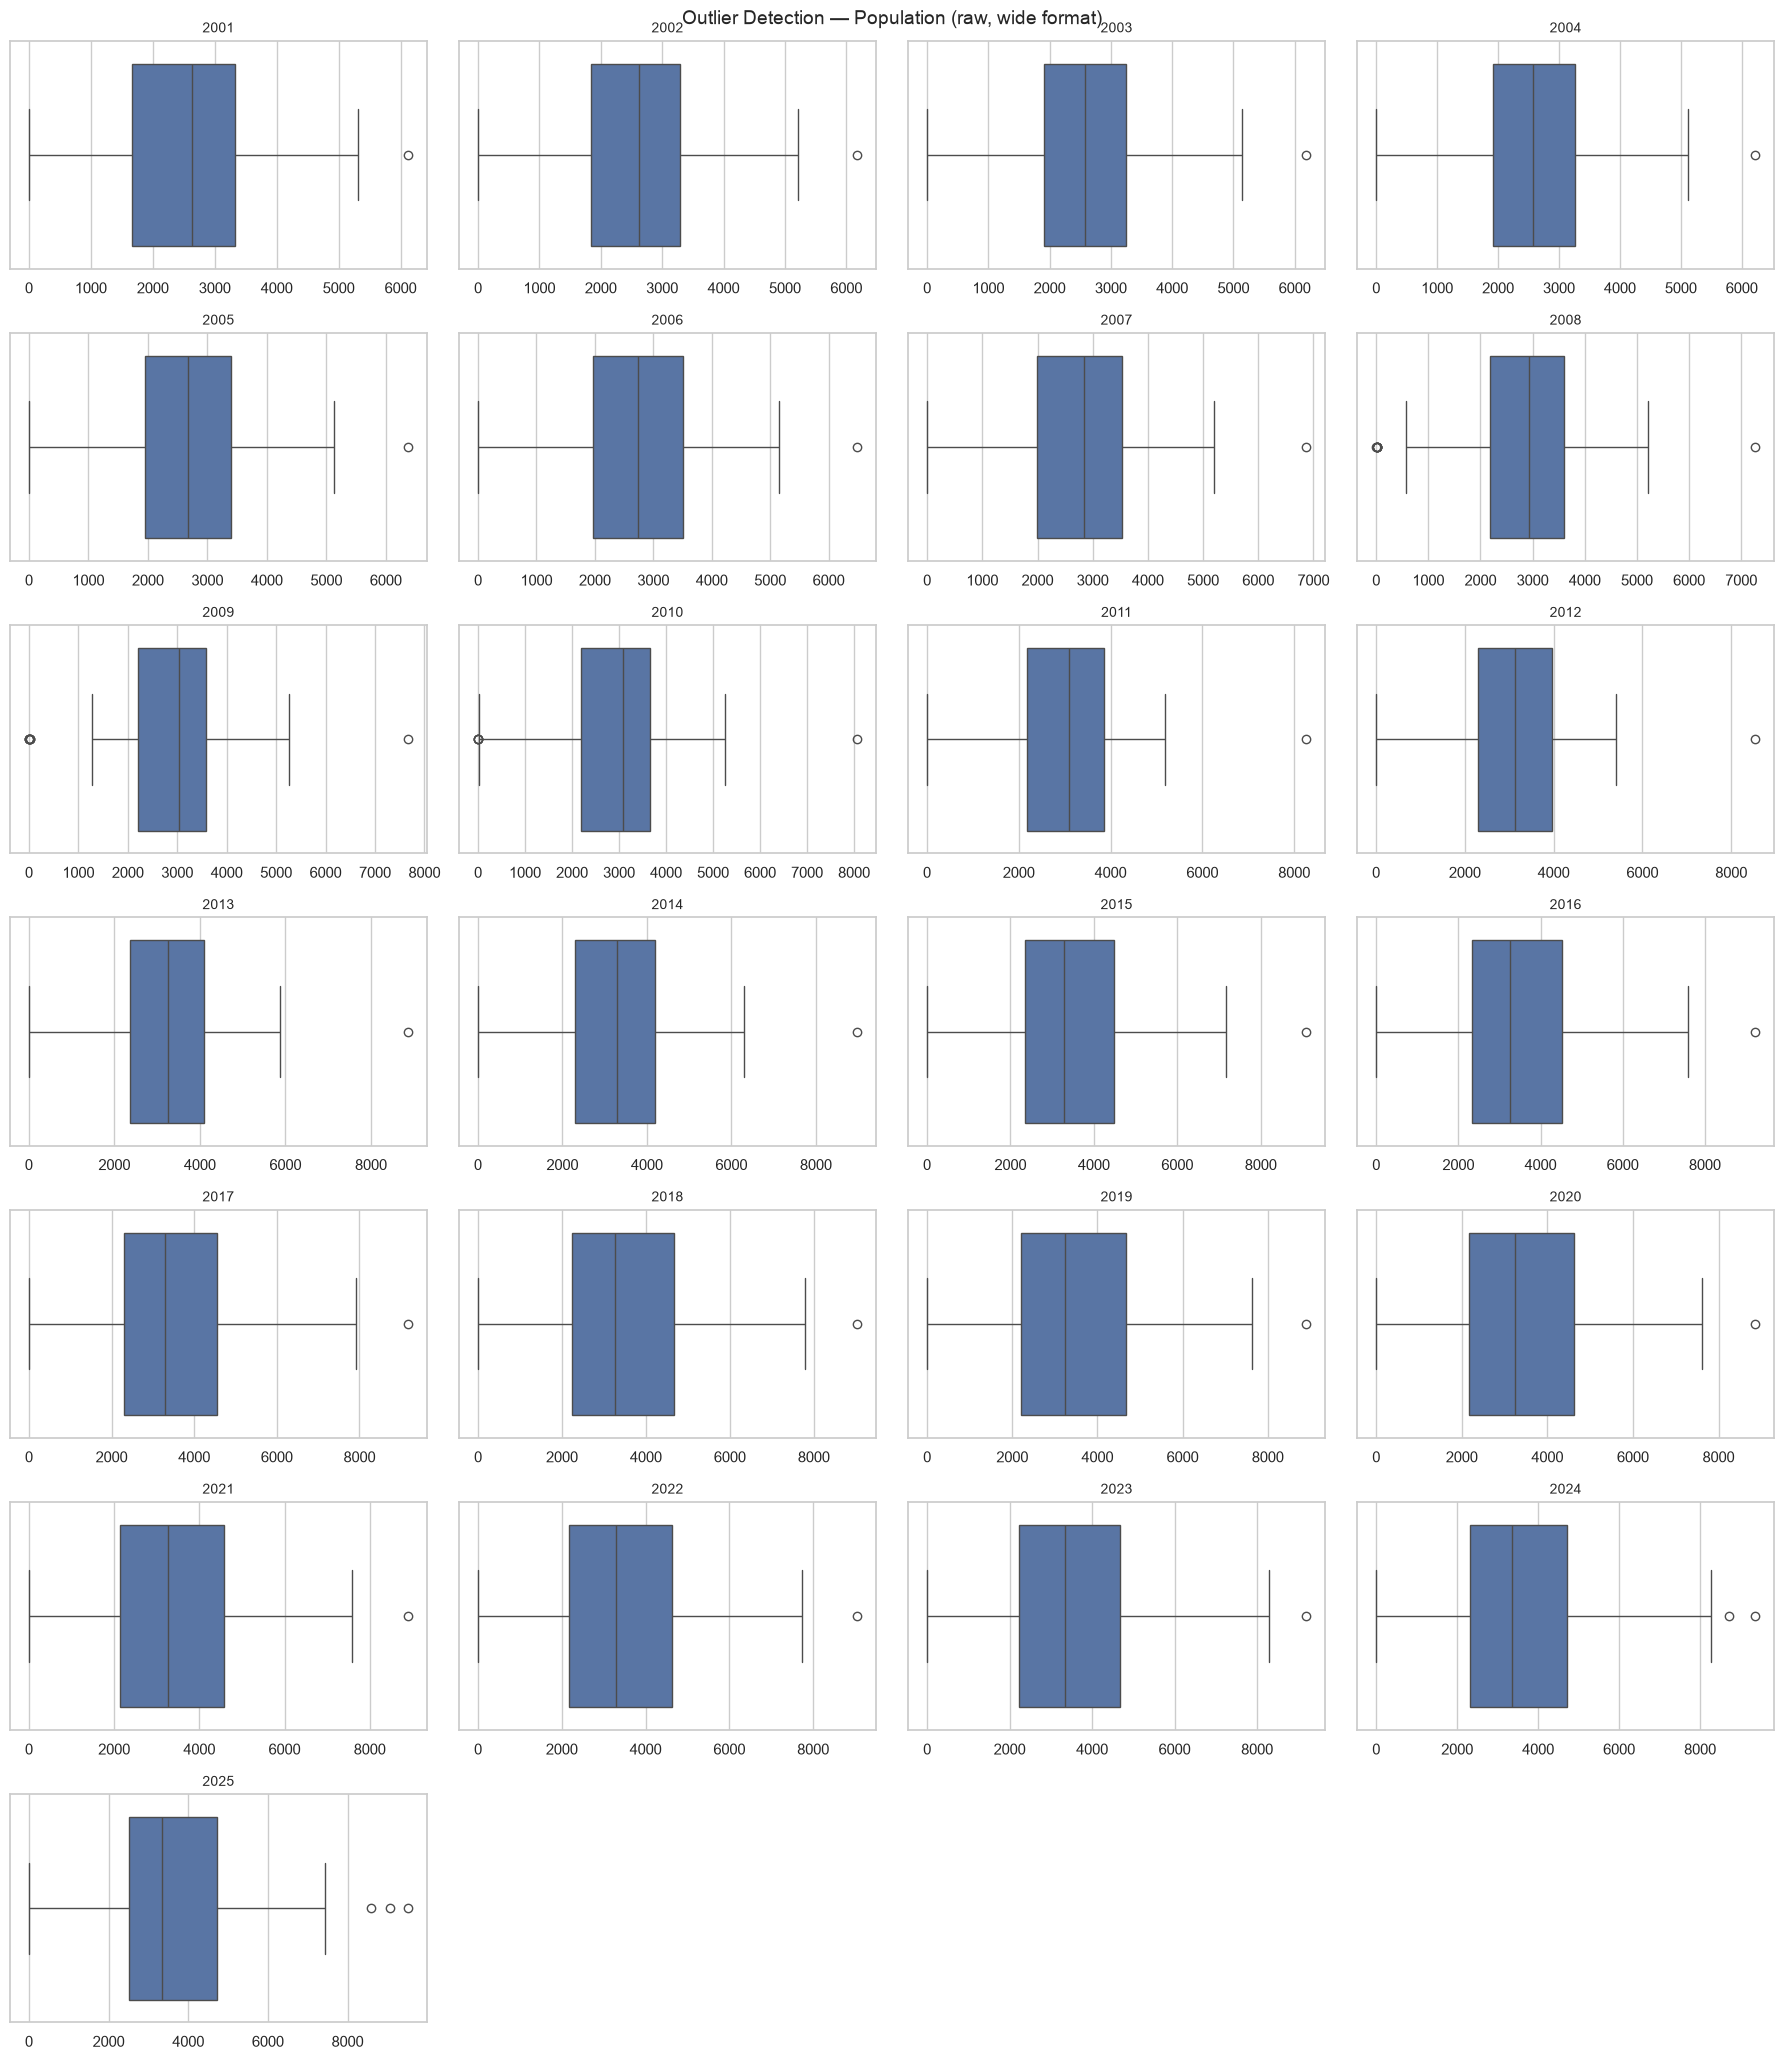

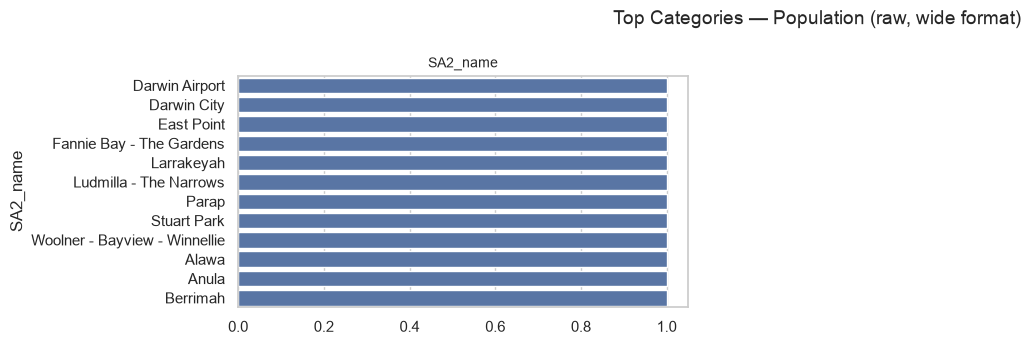

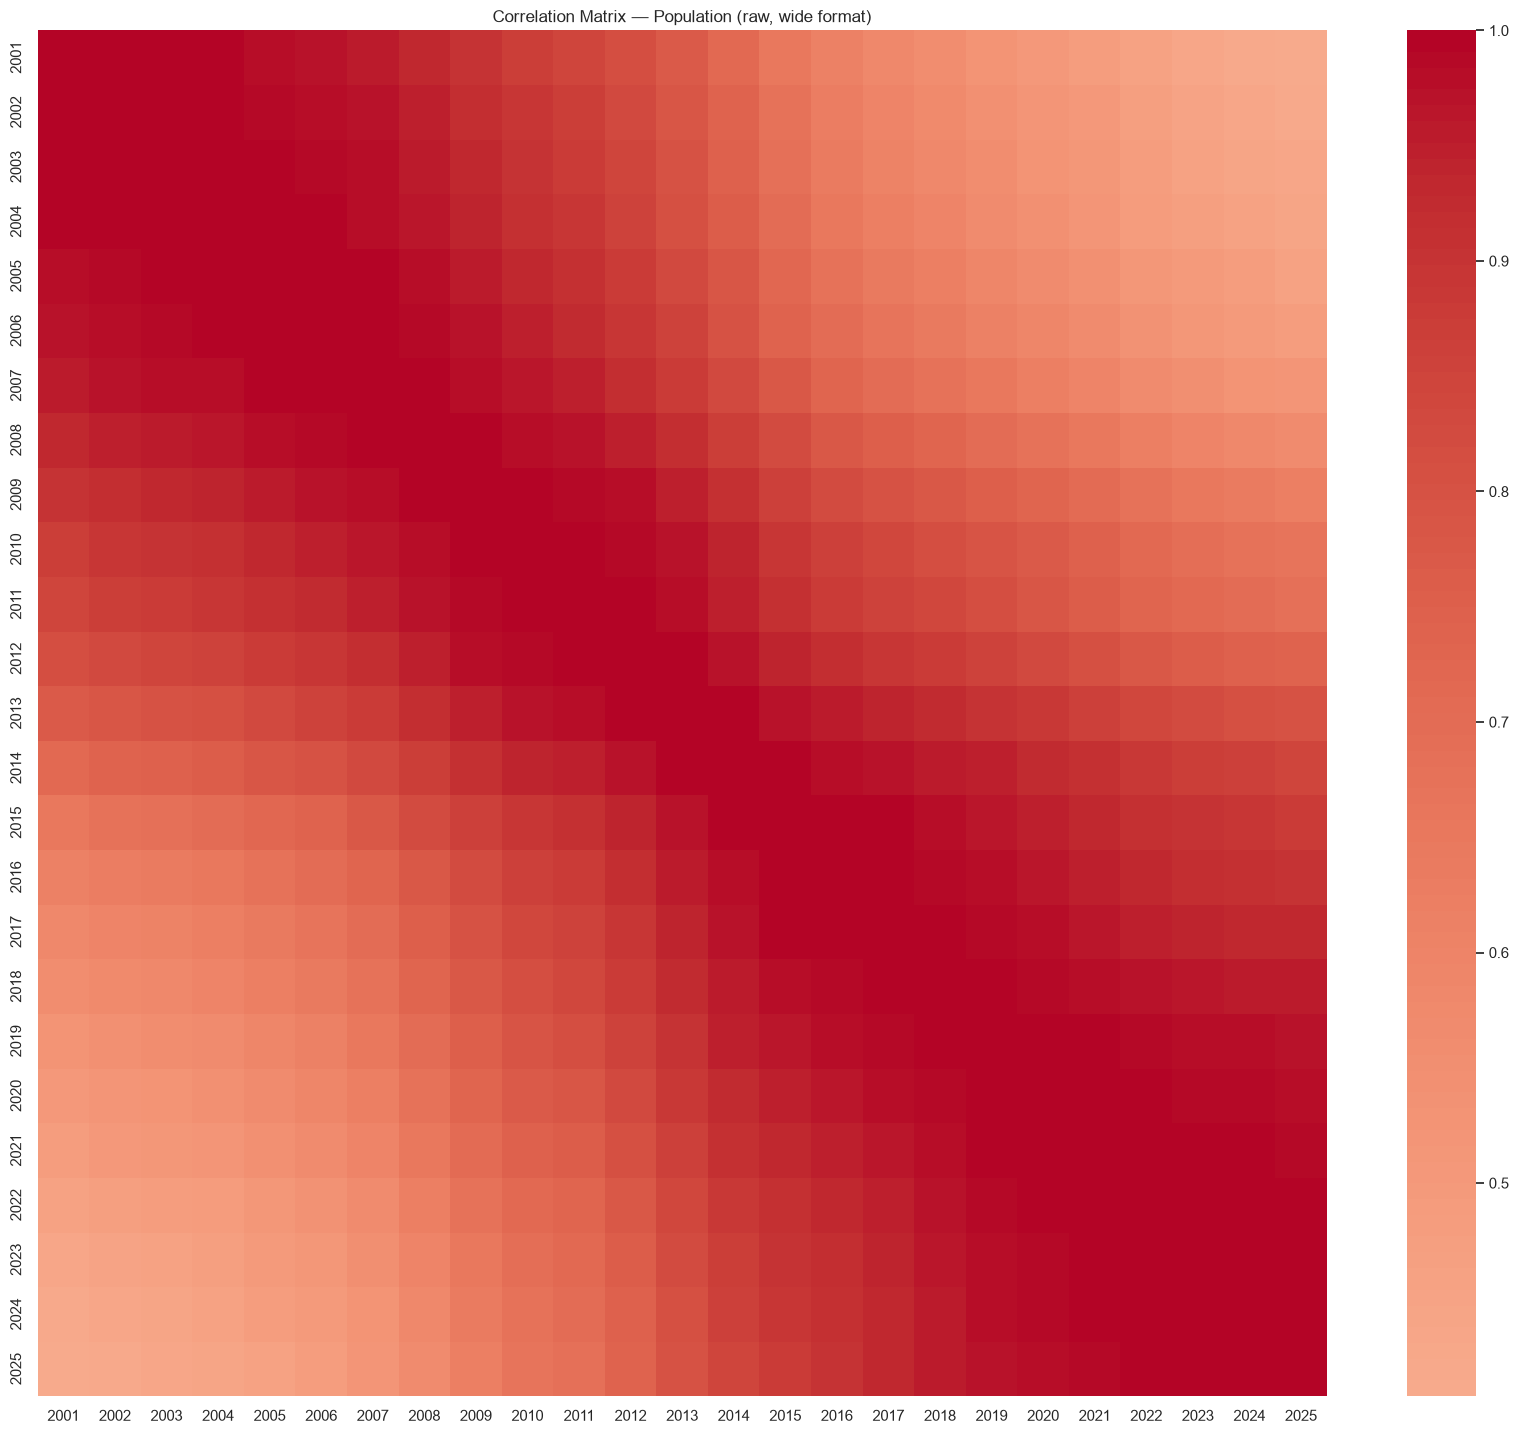

In [63]:
eda_population_raw = run_eda(population_processed, "Population (raw, wide format)")


Household Income (raw) — Structural Overview
Shape: 305 rows x 23 columns
Duplicate rows: 0

Missing %% by column:
pct_one_person_households                  14.4
pct_households_income_2000plus_weekly      14.4
pct_households_income_below_1000_weekly    14.4
population_density_per_sqkm                 0.7

Numeric summary — Household Income (raw)


,count,mean,std,min,25%,50%,75%,max
area_sqkm,305.0,4420.113092,11870.927296,0.0,3.880200,22.982900,511.788400,77873.089300
total_population,305.0,762.540984,1148.736056,0.0,59.000000,236.000000,806.000000,7149.000000
population_density_per_sqkm,303.0,288.863333,634.884385,0.0,0.014831,5.977177,91.364747,2676.405733
median_age_persons,305.0,33.203279,13.767500,0.0,27.000000,33.000000,39.000000,75.000000
median_personal_income_weekly_aud,305.0,707.068852,453.160312,0.0,281.000000,699.000000,1092.000000,2172.000000
median_family_income_weekly_aud,305.0,1489.934426,1044.330834,0.0,700.000000,1312.000000,2383.000000,5499.000000
median_household_income_weekly_aud,305.0,1494.032787,858.467916,0.0,900.000000,1424.000000,2090.000000,5500.000000
median_mortgage_repayment_monthly_aud,305.0,882.252459,1005.425021,0.0,0.000000,0.000000,1875.000000,4117.000000
median_rent_weekly_aud,305.0,160.822951,158.125205,0.0,25.000000,90.000000,300.000000,635.000000
average_persons_per_bedroom,305.0,1.083279,0.481994,0.0,0.900000,1.000000,1.300000,2.300000


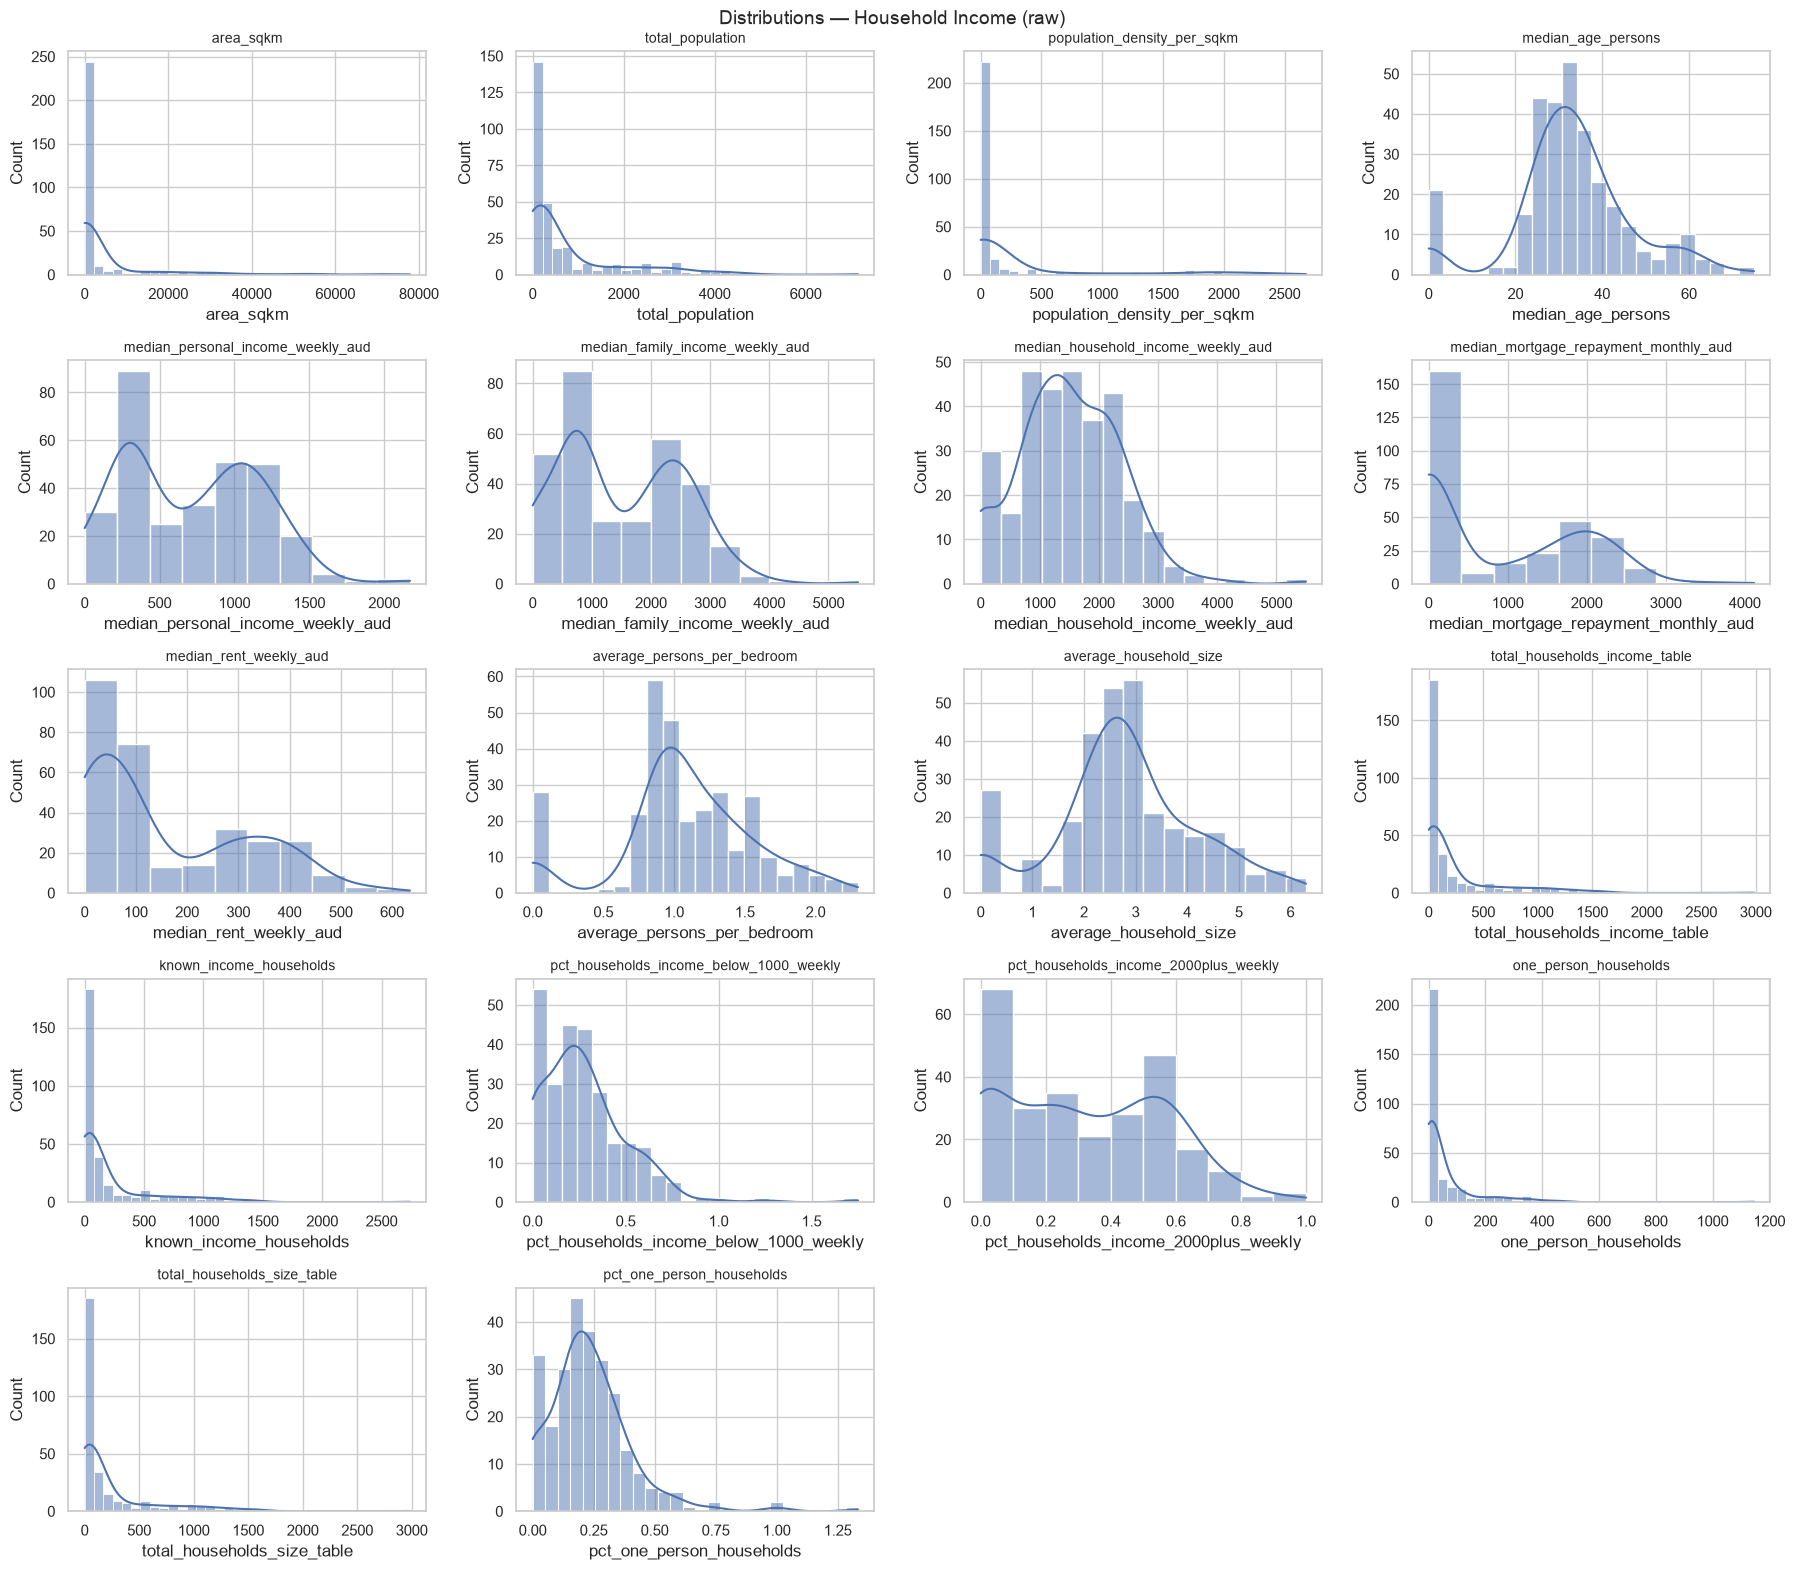

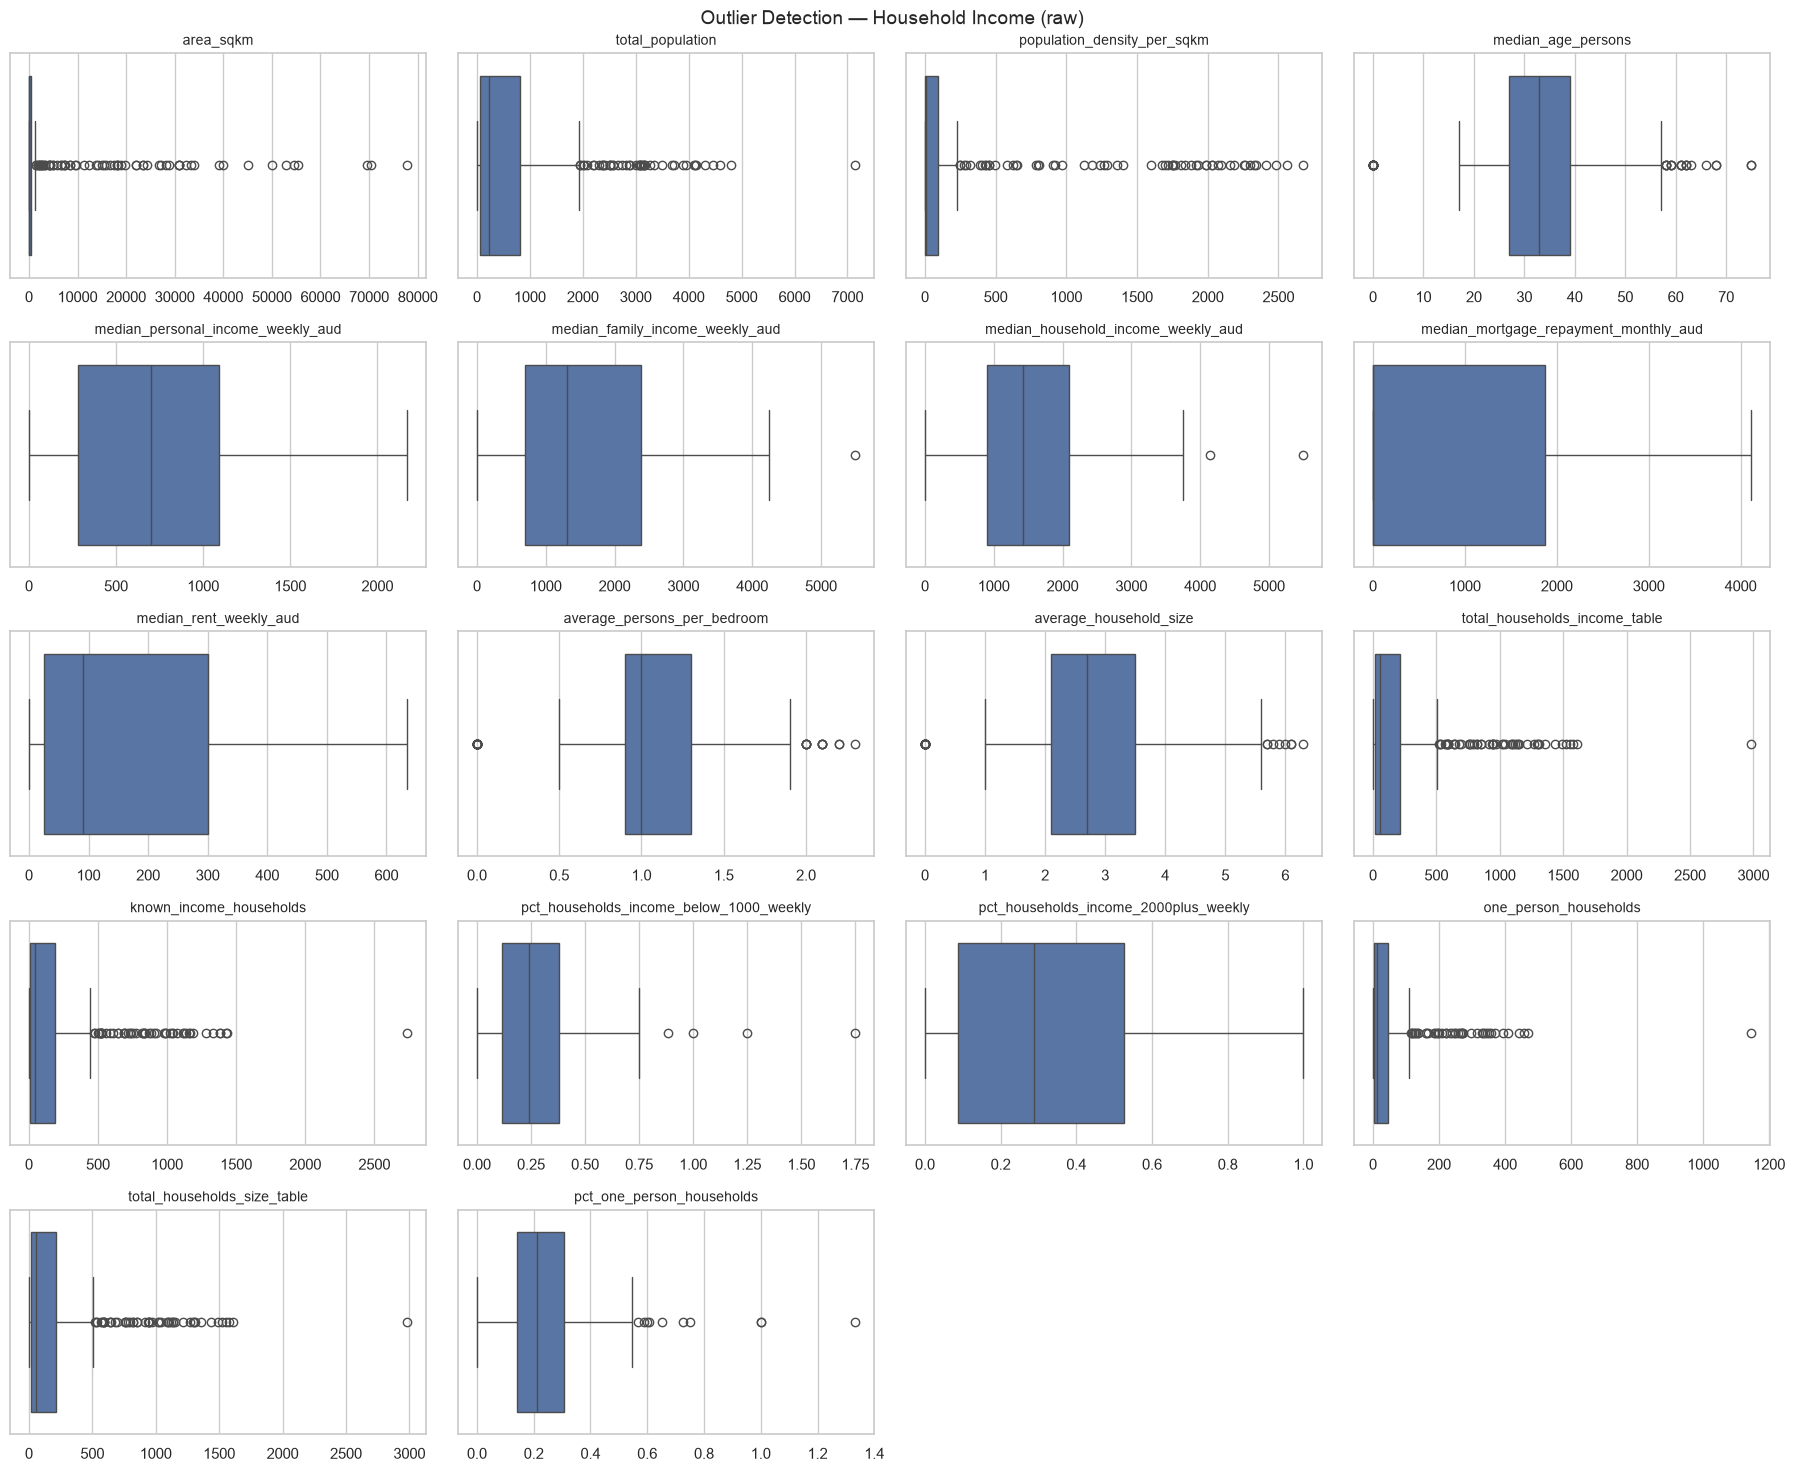

No categorical columns with a plottable cardinality for Household Income (raw).


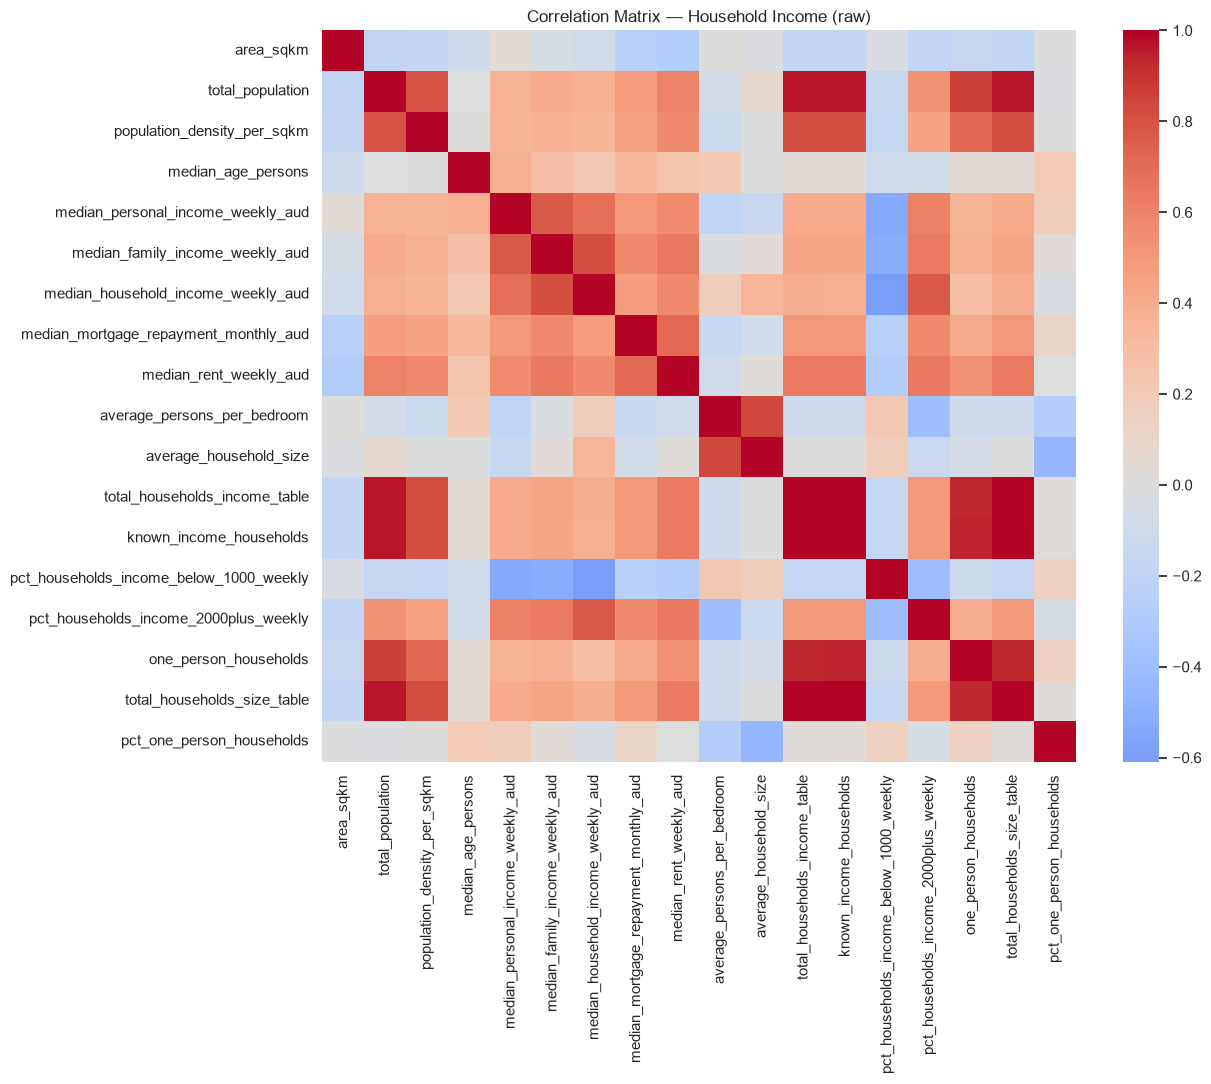

In [64]:
eda_household_raw = run_eda(household_income_processed, "Household Income (raw)")

### Insights from Round 1 → what we'll actually do in cleaning
Reading the overview/missingness output above:

- **`suburb` is a URL slug**, e.g. `"anula-nt-0812"`, not a name — it must be parsed into a
  clean suburb before it can be joined to the ABS `SA2_name` values ("Anula"). → parse it.
- **`land_area_m2` is text with a unit suffix** (`"985m²"`) → strip to a numeric column before
  it can be plotted, filtered, or modelled.
- **`price_undisclosed` is the string `"false"`/`"true"`**, not a boolean → coerce to 0/1.
- **`agent_name`/`agency_name` are missing for ~13,273 of 15,423 rows (~86%)** → far too sparse
  to impute meaningfully or use as a feature; we drop these columns rather than pretend we can
  fill them in.
- **`price_numeric`/`price_text` are both missing for ~5,088 rows (~33%)** — these are listings
  with no disclosed sale price. A model can't learn from a target it doesn't have, so these
  rows get **excluded from the modelling table**, not imputed (imputing a *price* would be
  fabricating the very thing we're trying to predict).
- **`latitude`/`longitude` are missing for 226 rows** → these can't get a `distance_from_cbd_km`
  feature, so they're dropped once we reach the feature-engineering step, not before.
- **`sold_date`/`sold_date_iso` are missing for 250 rows** → we lose the ability to look up
  that year's population for those rows specifically (handled with a fallback in Section 6).
- The boxplots flag likely **outliers in `price_numeric` and `land_area_m2`** (a few very large
  land parcels, a few extreme prices) → treated explicitly with an IQR filter in Section 5,
  rather than left in to distort the models.
- **Household income**: three related columns (`pct_one_person_households`,
  `pct_households_income_2000plus_weekly`, `pct_households_income_below_1000_weekly`) are all
  missing for the same ~14.4% of suburbs, and `population_density_per_sqkm` for ~0.7% → these
  are suburb-level census gaps, not row-level noise, so they get **suburb-aware** handling
  (fill from the same suburb's other known figures where possible, not a blanket global mean).
- **Population is in wide format** (`2001`…`2025` as separate columns) → not usable for a
  suburb+year lookup as-is; melt it to long (`suburb`, `year`, `population`) in Section 4.

## 4. Data Cleaning
Each step below is a direct response to one of the Round 1 findings above.

### 4.1 Properties

In [65]:
def parse_suburb_slug(slug):
    """Turns a URL slug like 'coconut-grove-nt-0810' into a clean suburb name
    like 'Coconut Grove', by stripping a trailing postcode and state-code token."""
    if pd.isna(slug):
        return np.nan
    parts = str(slug).strip().lower().split("-")
    if parts and parts[-1].isdigit():                                   # trailing postcode
        parts = parts[:-1]
    if parts and parts[-1].isalpha() and len(parts[-1]) <= 3:           # trailing state code
        parts = parts[:-1]
    return " ".join(p.capitalize() for p in parts) if parts else np.nan


def parse_land_area(value):
    """Strips unit suffixes like 'm²' from land area text and returns a float."""
    if pd.isna(value):
        return np.nan
    digits = re.sub(r"[^0-9.]", "", str(value))
    return float(digits) if digits else np.nan


def parse_bool_ish(value):
    """Handles 'true'/'false' strings (any case) as well as native booleans/0/1."""
    if isinstance(value, bool):
        return int(value)
    s = str(value).strip().lower()
    if s in ("true", "1", "yes"):
        return 1
    if s in ("false", "0", "no", "nan", ""):
        return 0
    return 0


properties = properties_processed.copy()

# Suburb: slug -> clean name, so it can later be joined to the ABS SA2_name values
properties["suburb_raw"] = properties["suburb"]
properties["suburb"] = properties["suburb_raw"].apply(parse_suburb_slug)

# Dates
properties["sold_date_iso"] = pd.to_datetime(properties["sold_date_iso"], errors="coerce")

# Land area: strip 'm²' etc.
properties["land_area_m2"] = properties["land_area_m2"].apply(parse_land_area)

# Undisclosed-price flag: string -> binary
properties["price_undisclosed"] = properties["price_undisclosed"].apply(parse_bool_ish)

# Price: coerce to numeric, with a fallback parse from price_text for rows where
# price_numeric didn't come through cleanly
properties["price_numeric"] = pd.to_numeric(properties["price_numeric"], errors="coerce")
needs_fallback = properties["price_numeric"].isna() & properties["price_text"].notna()
fallback_prices = (
    properties.loc[needs_fallback, "price_text"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
)
properties.loc[needs_fallback, "price_numeric"] = pd.to_numeric(fallback_prices, errors="coerce")
print(f"Recovered {int(needs_fallback.sum())} prices from price_text via fallback parsing.")

print("\nExample suburb parsing:")
print(properties[["suburb_raw", "suburb"]].drop_duplicates().head(8).to_string(index=False))

Recovered 0 prices from price_text via fallback parsing.

Example suburb parsing:
           suburb_raw        suburb
        anula-nt-0812         Anula
      bayview-nt-0820       Bayview
coconut-grove-nt-0810 Coconut Grove
  darwin-city-nt-0800   Darwin City
   fannie-bay-nt-0820    Fannie Bay
      jingili-nt-0810       Jingili
       karama-nt-0812        Karama
   larrakeyah-nt-0820    Larrakeyah


In [66]:
# Drop agent_name / agency_name: ~86% missing (Round 1 finding) -- not salvageable,
# not predictive of price, so we drop the columns rather than impute or leave them in.
properties = properties.drop(columns=["agent_name", "agency_name"], errors="ignore")

# Remove exact duplicate listings
n_before = len(properties)
properties = properties.drop_duplicates()
print(f"Removed {n_before - len(properties)} duplicate records ({len(properties)} remain).")

# Keep only rows that can actually train/evaluate a price model: a real, disclosed sale price.
# (We do NOT impute price -- that would mean fabricating the target itself.)
n_before = len(properties)
properties = properties[(properties["price_undisclosed"] == 0) & (properties["price_numeric"].notna())].copy()
print(f"Dropped {n_before - len(properties)} rows with no disclosed price "
      f"({len(properties)} usable rows remain).")

missing_pct = properties.isna().mean().sort_values(ascending=False) * 100
print("\nMissing % by column (Properties, post-cleaning):")
print(missing_pct[missing_pct > 0].round(1))

Removed 0 duplicate records (15423 remain).
Dropped 5088 rows with no disclosed price (10335 usable rows remain).

Missing % by column (Properties, post-cleaning):
land_area_m2     36.8
longitude         1.2
latitude          1.2
sold_date         0.0
sold_date_iso     0.0
dtype: float64


### 4.2 Household Income

In [86]:
household_income = household_income_processed.copy()
household_income["SA2_name"] = household_income["SA2_name"].astype(str).str.strip().str.title()

if "census_year" in household_income.columns:
    n_years = household_income.groupby("SA2_name")["census_year"].nunique()
    if (n_years > 1).any():
        household_income = (
            household_income.sort_values("census_year")
            .drop_duplicates(subset=["SA2_name"], keep="last")
        )
        print("Multiple census years found per suburb -- kept the most recent.")
    else:
        print("Confirmed: exactly one census_year per suburb, nothing to deduplicate.")

missing_pct = household_income.isna().mean().sort_values(ascending=False) * 100
print("\nMissing % by column (ABS household income):")
print(missing_pct[missing_pct > 0].round(1))

household_income.head(2)

Confirmed: exactly one census_year per suburb, nothing to deduplicate.

Missing % by column (ABS household income):
pct_one_person_households                  14.4
pct_households_income_2000plus_weekly      14.4
pct_households_income_below_1000_weekly    14.4
population_density_per_sqkm                 0.7
dtype: float64


,SAL_CODE_2021,SA2_name,census_year,area_sqkm,total_population,population_density_per_sqkm,median_age_persons,median_personal_income_weekly_aud,median_family_income_weekly_aud,median_household_income_weekly_aud,median_mortgage_repayment_monthly_aud,median_rent_weekly_aud,average_persons_per_bedroom,average_household_size,total_households_income_table,known_income_households,pct_households_income_below_1000_weekly,pct_households_income_2000plus_weekly,one_person_households,total_households_size_table,pct_one_person_households,in_realestate_sample_suburbs,source
0,SAL70003,Alawa,2021,1.2399,2078,1675.941608,35,915,2186,2083,1777,340,0.9,2.8,679,612,0.245098,0.513072,118,679,0.173785,True,ABS 2021 Census General Community Profile Data...
1,SAL70014,Anula,2021,1.3178,2385,1809.834573,37,1034,2492,2269,2000,400,0.9,2.9,760,687,0.183406,0.567686,125,760,0.164474,True,ABS 2021 Census General Community Profile Data...


### 4.3 Population
`population.csv` stores one column per year (2001–2025). We reshape it into a long/tidy format (`suburb`, `year`, `population`) so it can be merged against each property's sale year.

In [68]:
population = population_processed.copy()
population["SA2_name"] = population["SA2_name"].astype(str).str.strip().str.title()

year_cols = [c for c in population.columns if str(c).isdigit()]
population_long = population.melt(
    id_vars="SA2_name", value_vars=year_cols, var_name="year", value_name="population"
)
population_long["year"] = population_long["year"].astype(int)
population_long = population_long.rename(columns={"SA2_name": "suburb"})

print(f"Reshaped population data: {population.shape} (wide) -> {population_long.shape} (long)")
population_long.head()

Reshaped population data: (44, 26) (wide) -> (1100, 3) (long)


,suburb,year,population
0,Darwin Airport,2001,23
1,Darwin City,2001,2140
2,East Point,2001,0
3,Fannie Bay - The Gardens,2001,3392
4,Larrakeyah,2001,3301


## 5. Outlier Treatment (IQR)
The Round 1 boxplots flagged extreme values in `price_numeric` and `land_area_m2`. We apply a
standard IQR filter (values outside `Q1 - 1.5*IQR` to `Q3 + 1.5*IQR` are removed) — consistent
with the "define clean / trace errors / change thoughtfully" principle from the Week 2 lecture:
we report exactly how many rows are removed and why, rather than silently dropping them.

In [69]:
def iqr_filter(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        if col not in df.columns:
            continue
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        col_mask = df[col].between(lower, upper) | df[col].isna()
        removed = (~col_mask).sum()
        print(f"{col}: removing {removed} rows outside [{lower:,.0f}, {upper:,.0f}]")
        mask &= col_mask
    return df[mask].copy()

n_before = len(properties)
properties = iqr_filter(properties, ["price_numeric", "land_area_m2"])
print(f"\nTotal removed by IQR filtering: {n_before - len(properties)} "
      f"({len(properties)} rows remain).")

price_numeric: removing 337 rows outside [10,000, 1,050,000]
land_area_m2: removing 1013 rows outside [-380, 1,700]

Total removed by IQR filtering: 1282 (9053 rows remain).


## 6. Feature Engineering

### 6.1 Distance from Darwin CBD

In [70]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

# Round 1 flagged 226 rows with no lat/long -- distance can't be computed for these,
# so we drop them here rather than earlier (they were still useful for the EDA above).
n_before = len(properties)
properties = properties.dropna(subset=["latitude", "longitude"]).copy()
print(f"Dropped {n_before - len(properties)} rows with missing coordinates.")

properties["distance_from_cbd_km"] = haversine_km(
    properties["latitude"], properties["longitude"], DARWIN_CBD_LAT, DARWIN_CBD_LON
)
properties["distance_from_cbd_km"].describe()

Dropped 93 rows with missing coordinates.


count     8960.000000
mean        69.733026
std        758.478173
min          0.013135
25%          5.047482
50%         10.906102
75%         15.695858
max      18262.529709
Name: distance_from_cbd_km, dtype: float64

### 6.2 Merge with Population (suburb + sale year) and Household Income (suburb)
Population is time-varying, so it's matched on **suburb and the property's own sale year**
(falling back to the nearest year in range when the sale date is missing or outside 2001–2025).
Household income is a single census snapshot, so it's matched on **suburb only**.

In [71]:
properties["sale_year"] = properties["sold_date_iso"].dt.year

min_year, max_year = population_long["year"].min(), population_long["year"].max()
properties["lookup_year"] = properties["sale_year"].clip(lower=min_year, upper=max_year)
properties["lookup_year"] = properties["lookup_year"].fillna(max_year)

model_df = properties.merge(
    population_long,
    left_on=["suburb", "lookup_year"],
    right_on=["suburb", "year"],
    how="left",
)

household_income_dedup = household_income.drop_duplicates(subset="SA2_name")
model_df = model_df.merge(
    household_income_dedup.rename(columns={"SA2_name": "suburb"}),
    on="suburb",
    how="left",
)

match_rate_pop = model_df["population"].notna().mean() * 100
match_rate_income = model_df["median_household_income_weekly_aud"].notna().mean() * 100
print(f"Population match rate:        {match_rate_pop:.1f}% of rows matched a suburb+year")
print(f"Household income match rate:  {match_rate_income:.1f}% of rows matched a suburb")
if match_rate_pop < 90 or match_rate_income < 90:
    print("\n-> Low match rate suggests suburb-name mismatches between datasets "
          "(e.g. hyphenated ABS names). Worth a manual look at the unmatched suburbs below.")

unmatched_suburbs = sorted(model_df.loc[model_df["median_household_income_weekly_aud"].isna(), "suburb"].unique())
print(f"\nSuburbs with no household-income match ({len(unmatched_suburbs)}):")
print(unmatched_suburbs[:20])

Population match rate:        62.3% of rows matched a suburb+year
Household income match rate:  100.0% of rows matched a suburb

-> Low match rate suggests suburb-name mismatches between datasets (e.g. hyphenated ABS names). Worth a manual look at the unmatched suburbs below.

Suburbs with no household-income match (2):
['Northlakes', 'Rosebery Heights']


### 6.3 Handling Missing Values After Merge
We only impute *after* merging, using suburb-level medians first (falling back to the global
median only if an entire suburb is missing a figure) — this avoids polluting one suburb's
values with statistics from suburbs that never appear in `properties.csv`.

In [72]:
numeric_impute_cols = [
    "land_area_m2", "population", "median_household_income_weekly_aud",
    "median_personal_income_weekly_aud", "median_rent_weekly_aud",
    "population_density_per_sqkm", "median_age_persons", "average_household_size",
]
numeric_impute_cols = [c for c in numeric_impute_cols if c in model_df.columns]

for col in numeric_impute_cols:
    before_missing = model_df[col].isna().sum()
    suburb_median = model_df.groupby("suburb")[col].transform("median")
    model_df[col] = model_df[col].fillna(suburb_median)
    model_df[col] = model_df[col].fillna(model_df[col].median())
    after_missing = model_df[col].isna().sum()
    if before_missing:
        print(f"{col}: filled {before_missing - after_missing} values "
              f"(suburb median, then global median as a fallback)")

model_df = model_df.drop(columns=["year", "lookup_year", "suburb_raw", "SAL_CODE_2021", "source"], errors="ignore")
print(f"\nFinal modelling table: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")

land_area_m2: filled 3658 values (suburb median, then global median as a fallback)
population: filled 3378 values (suburb median, then global median as a fallback)
median_household_income_weekly_aud: filled 3 values (suburb median, then global median as a fallback)
median_personal_income_weekly_aud: filled 3 values (suburb median, then global median as a fallback)
median_rent_weekly_aud: filled 3 values (suburb median, then global median as a fallback)
population_density_per_sqkm: filled 3 values (suburb median, then global median as a fallback)
median_age_persons: filled 3 values (suburb median, then global median as a fallback)
average_household_size: filled 3 values (suburb median, then global median as a fallback)

Final modelling table: 8,960 rows x 39 columns


## 7. EDA — Round 2 (Cleaned & Merged Data)
This is the exact same `run_eda()` call as Round 1 — same functions, no new code — but now on
the cleaned, merged modelling table, and this time **with a target**. That's the point of
building it as reusable functions: nothing needed to be rewritten to run EDA again after
cleaning and feature engineering.


Final Modelling Dataset (post-cleaning) — Structural Overview
Shape: 8,960 rows x 39 columns
Duplicate rows: 0

Missing %% by column:
census_year                                0.0
sale_year                                  0.0
pct_one_person_households                  0.0
total_households_size_table                0.0
one_person_households                      0.0
pct_households_income_2000plus_weekly      0.0
pct_households_income_below_1000_weekly    0.0
known_income_households                    0.0
total_households_income_table              0.0
average_persons_per_bedroom                0.0
median_mortgage_repayment_monthly_aud      0.0
median_family_income_weekly_aud            0.0
total_population                           0.0
area_sqkm                                  0.0
in_realestate_sample_suburbs               0.0
sold_date                                  0.0
sold_date_iso                              0.0

Numeric summary — Final Modelling Dataset (post-cleaning)


,count,mean,std,min,25%,50%,75%,max
price_numeric,8960.0,520539.559821,180442.807722,35000.000000,390000.000000,505000.000000,635000.000000,1.050000e+06
beds,8960.0,3.018527,1.057923,0.000000,2.000000,3.000000,4.000000,2.000000e+01
baths,8960.0,1.688504,0.629804,0.000000,1.000000,2.000000,2.000000,7.000000e+00
cars,8960.0,2.104576,1.147801,0.000000,2.000000,2.000000,2.000000,1.600000e+01
land_area_m2,8960.0,551.118522,305.179967,1.000000,245.000000,609.000000,813.000000,1.680000e+03
distance_from_cbd_km,8960.0,69.733026,758.478173,0.013135,5.047482,10.906102,15.695858,1.826253e+04
population,8960.0,4027.041071,1596.917041,1709.000000,3372.000000,3497.000000,4290.000000,9.513000e+03
median_household_income_weekly_aud,8960.0,2208.753348,360.997099,675.000000,2022.000000,2223.000000,2397.000000,3.630000e+03
median_rent_weekly_aud,8960.0,394.959152,69.377269,180.000000,350.000000,400.000000,450.000000,5.600000e+02
population_density_per_sqkm,8960.0,1798.283282,597.384949,2.160317,1398.617336,1883.843881,2253.001796,2.676406e+03


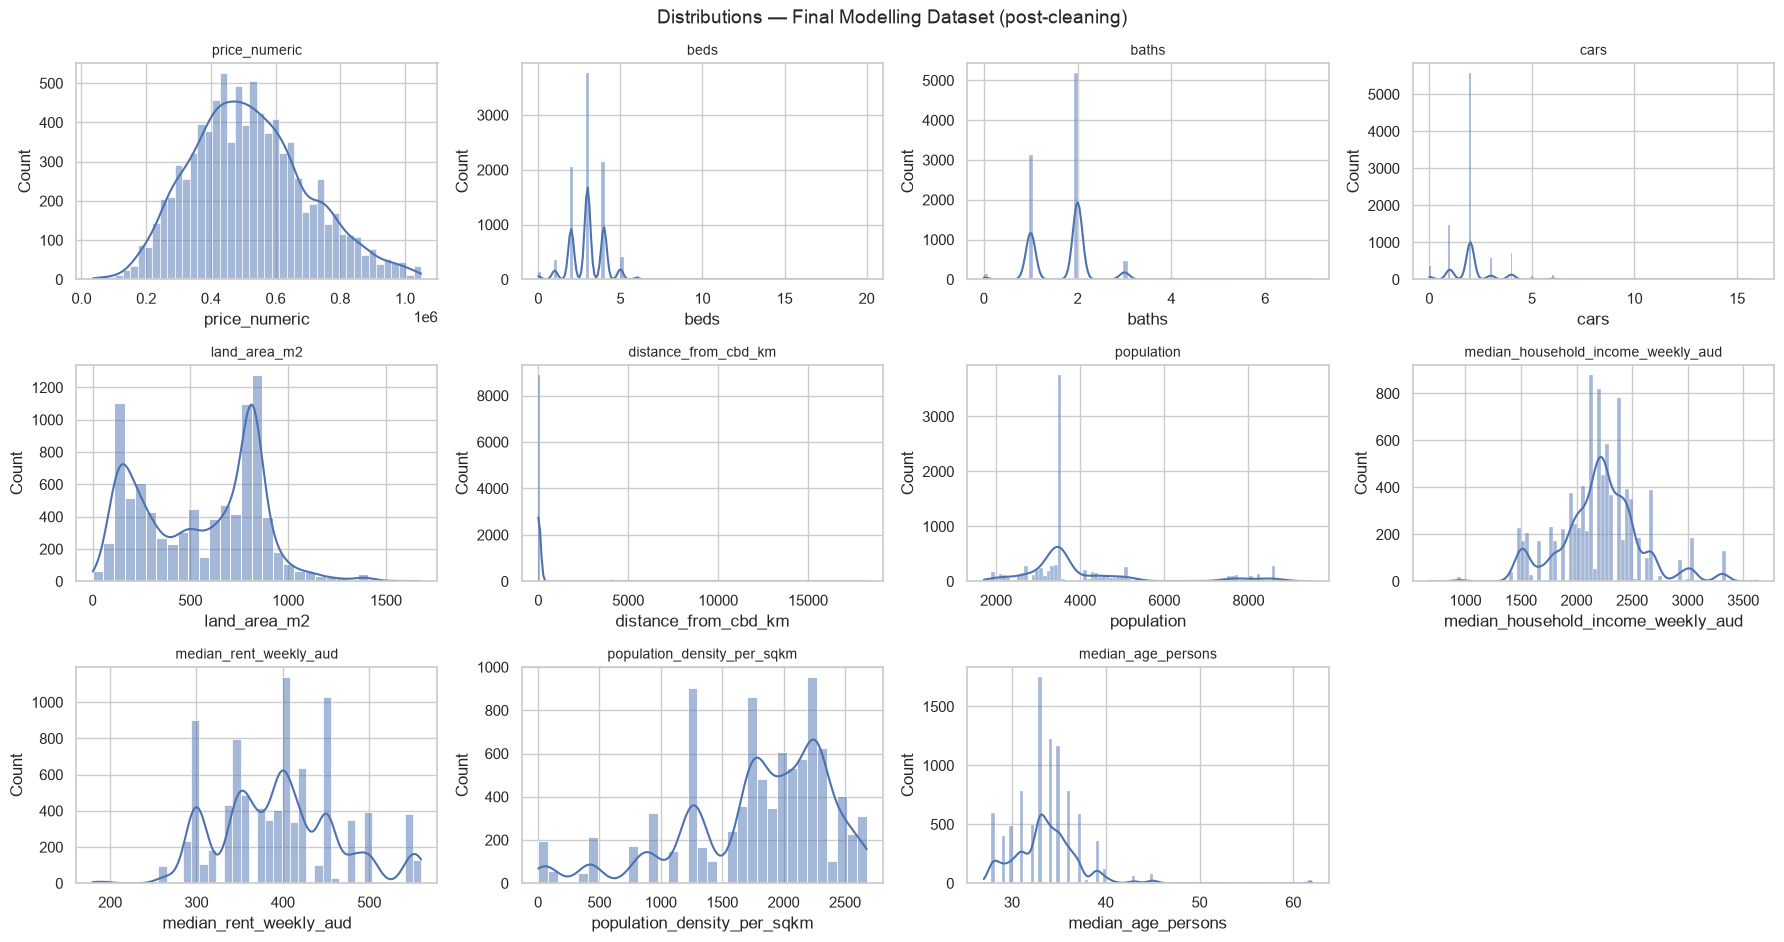

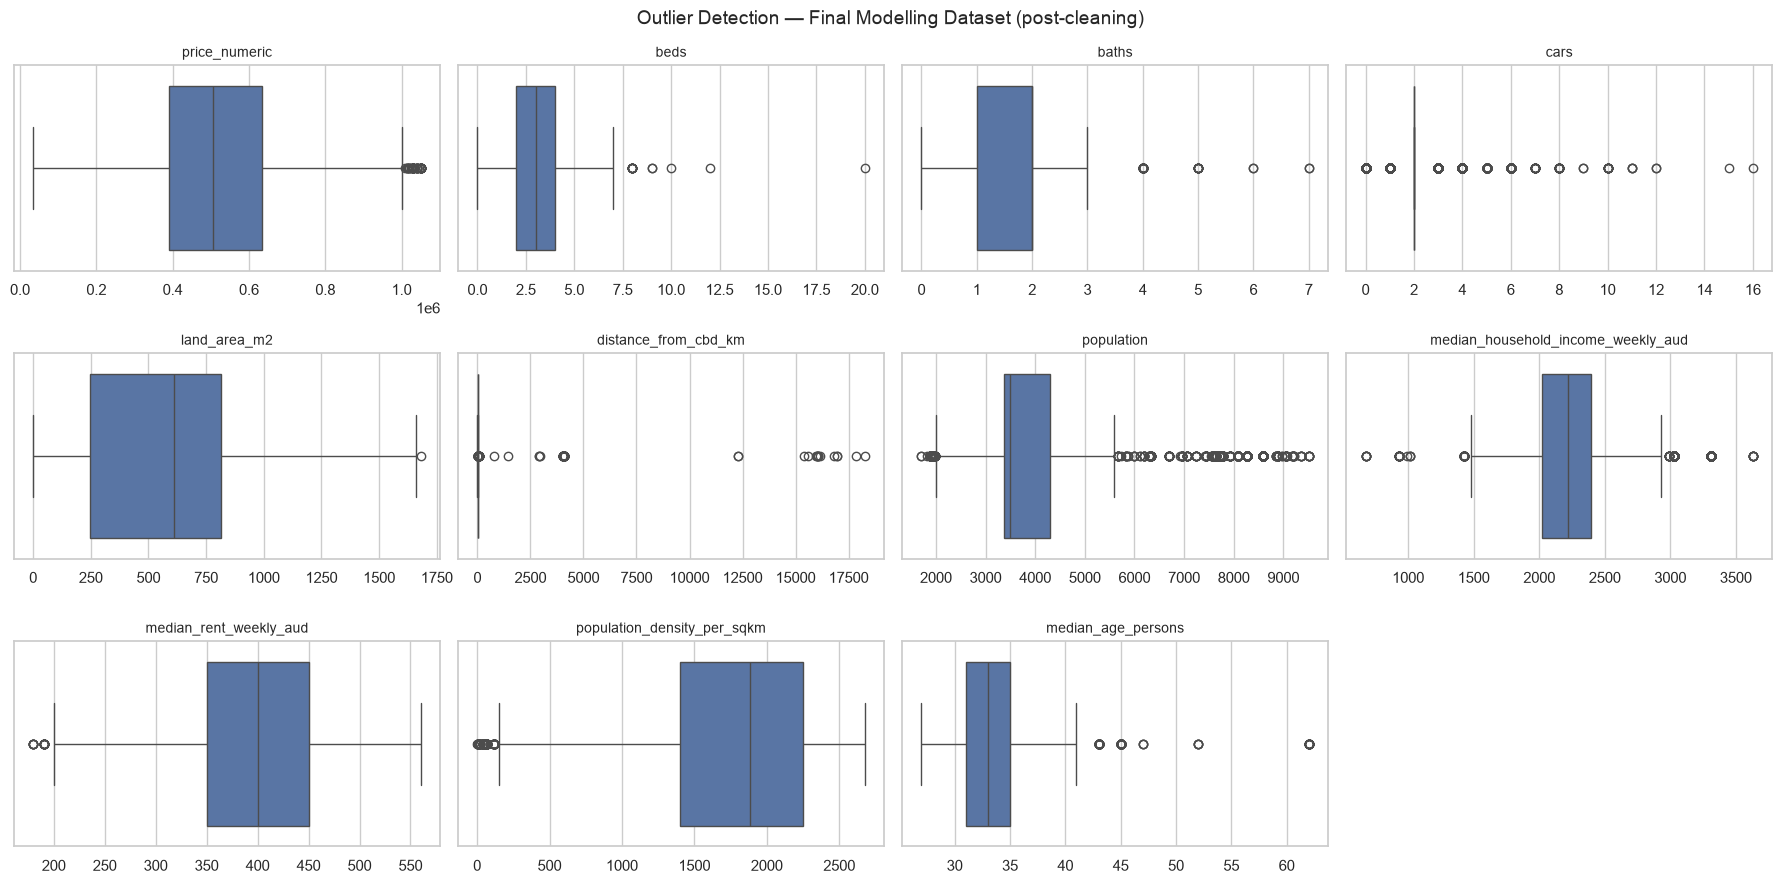

No categorical columns with a plottable cardinality for Final Modelling Dataset (post-cleaning).


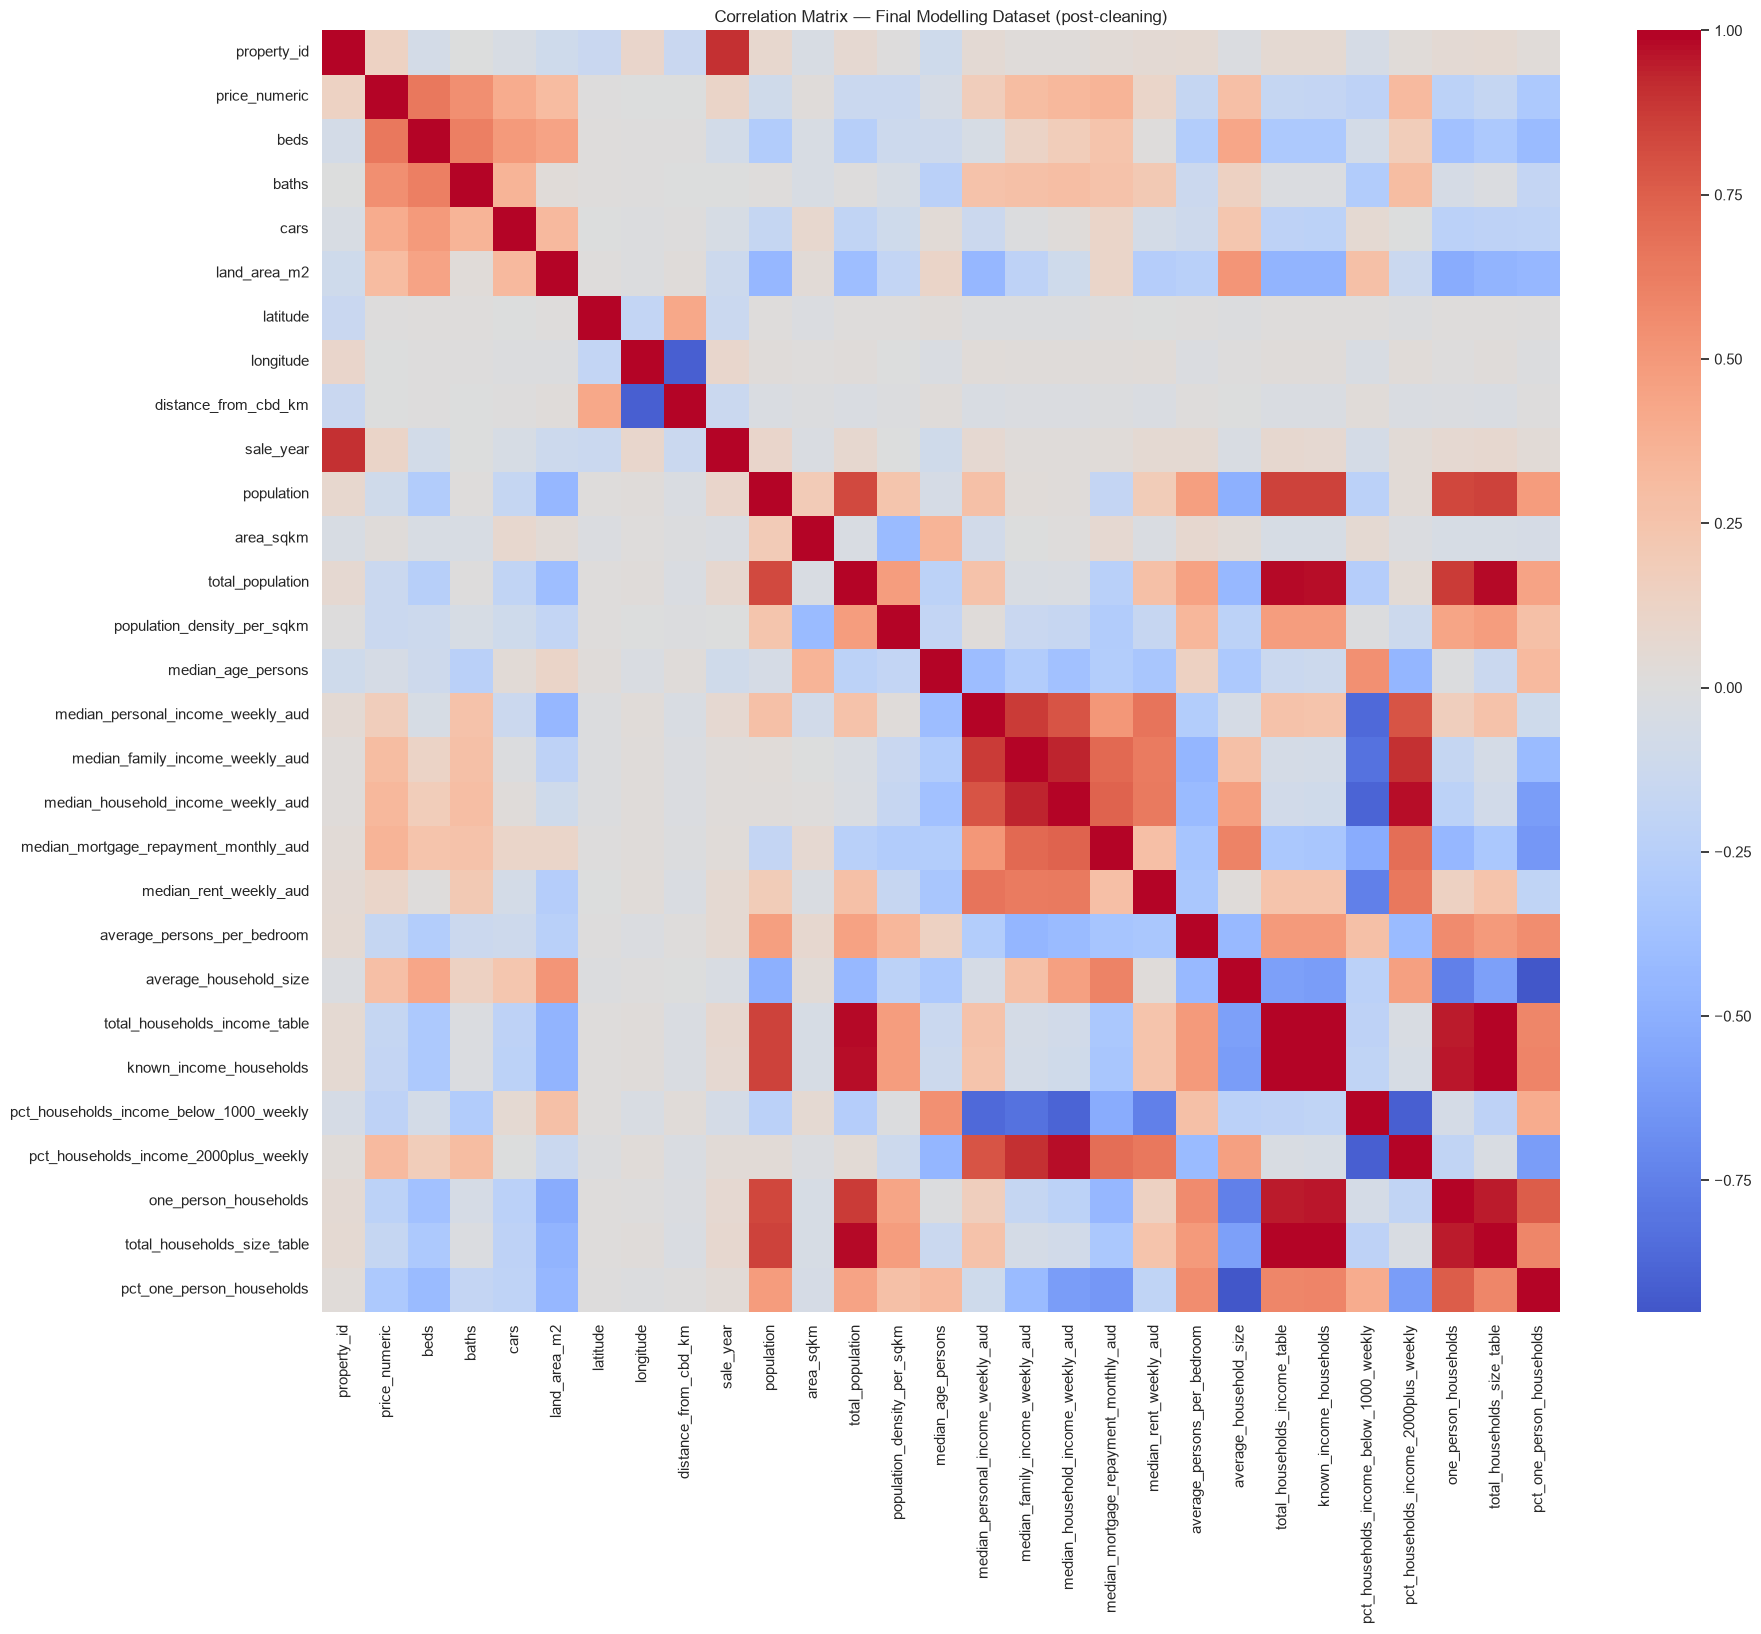

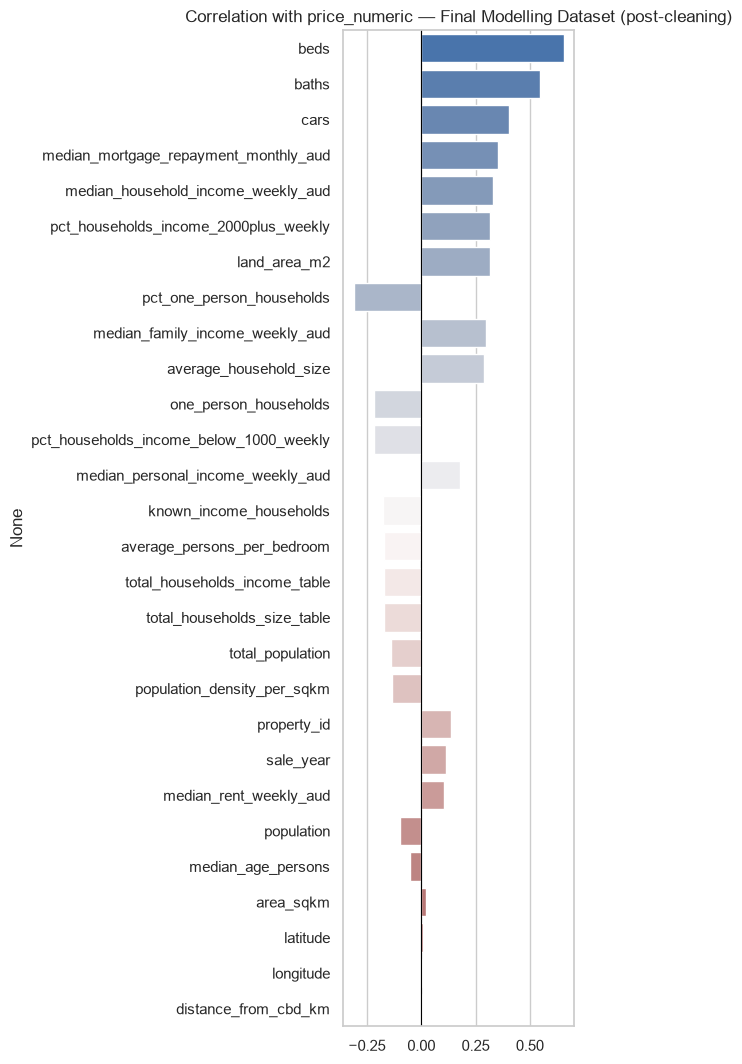


Strongest correlations with price_numeric:
beds                                       0.655
baths                                      0.546
cars                                       0.404
median_mortgage_repayment_monthly_aud      0.354
median_household_income_weekly_aud         0.330
pct_households_income_2000plus_weekly      0.316
land_area_m2                               0.314
pct_one_person_households                 -0.311
median_family_income_weekly_aud            0.299
average_household_size                     0.289
one_person_households                     -0.219
pct_households_income_below_1000_weekly   -0.217
median_personal_income_weekly_aud          0.176
known_income_households                   -0.175
average_persons_per_bedroom               -0.171
total_households_income_table             -0.171
total_households_size_table               -0.171
total_population                          -0.139
population_density_per_sqkm               -0.137
property_id              

In [73]:
numeric_features_for_eda = [
    "price_numeric", "beds", "baths", "cars", "land_area_m2", "distance_from_cbd_km",
    "population", "median_household_income_weekly_aud", "median_rent_weekly_aud",
    "population_density_per_sqkm", "median_age_persons",
]
numeric_features_for_eda = [c for c in numeric_features_for_eda if c in model_df.columns]

eda_final = run_eda(
    model_df, "Final Modelling Dataset (post-cleaning)",
    target="price_numeric",
    numeric_cols=numeric_features_for_eda,
    categorical_cols=["suburb", "status"],
)

In [87]:
# Turn the correlation output into an explicit feature-selection decision, rather
# than just looking at the chart and deciding by eye.
target_corr = eda_final["correlation"]["target_corr"]

CORR_THRESHOLD = 0.05
if target_corr is not None:
    weak_features = target_corr[target_corr.abs() < CORR_THRESHOLD].index.tolist()
    strong_features = target_corr[target_corr.abs() >= CORR_THRESHOLD].index.tolist()
    print(f"Features with |correlation| >= {CORR_THRESHOLD} with price_numeric (kept):")
    print(target_corr.loc[strong_features].round(3).to_string())
    if weak_features:
        print(f"\nFeatures below the threshold (candidates to drop as numeric predictors):")
        print(target_corr.loc[weak_features].round(3).to_string())

price_skew = model_df["price_numeric"].skew()
print(f"\nprice_numeric skew: {price_skew:.2f}")

Features with |correlation| >= 0.05 with price_numeric (kept):
beds                                       0.655
baths                                      0.546
cars                                       0.404
median_mortgage_repayment_monthly_aud      0.354
median_household_income_weekly_aud         0.330
pct_households_income_2000plus_weekly      0.316
land_area_m2                               0.314
pct_one_person_households                 -0.311
median_family_income_weekly_aud            0.299
average_household_size                     0.289
one_person_households                     -0.219
pct_households_income_below_1000_weekly   -0.217
median_personal_income_weekly_aud          0.176
known_income_households                   -0.175
average_persons_per_bedroom               -0.171
total_households_income_table             -0.171
total_households_size_table               -0.171
total_population                          -0.139
population_density_per_sqkm               -0.137
proper

### Insights from Round 2 → modelling decisions

- Whichever features come out **strongest** (land area, beds/baths, distance from CBD,
  household income are the usual suspects for a housing dataset) go into the model as the
  numeric feature set below — that ranking *is* the feature-selection decision, not a guess.
- `distance_from_cbd_km` typically comes out **negative** — further from the CBD, lower price —
  which is a sanity check that the feature was engineered correctly, not just noise.
- `suburb` and `status` are kept as **categorical** features (one-hot encoded) rather than
  numeric, since Darwin suburb effects on price aren't linear or ordered.
- Any suburb-mismatch rows found in Section 6.2 (no income data) still have suburb-median
  imputed values, so they aren't dropped — losing rows just to avoid imputation would shrink
  an already-filtered dataset for no real benefit.

## 8. Prepare Modelling Dataset

In [75]:
TARGET = "price_numeric"

numeric_features = [
    "beds", "baths", "cars", "land_area_m2", "distance_from_cbd_km",
    "population", "median_household_income_weekly_aud", "median_personal_income_weekly_aud",
    "median_rent_weekly_aud", "population_density_per_sqkm", "median_age_persons",
    "average_household_size",
]
numeric_features = [c for c in numeric_features if c in model_df.columns]

categorical_features = [c for c in ["suburb", "status"] if c in model_df.columns]

feature_cols = numeric_features + categorical_features
model_data = model_df.dropna(subset=[TARGET]).copy()

X = model_data[feature_cols]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows   Features: {len(feature_cols)}")

Train: 7,168 rows   Test: 1,792 rows   Features: 14


In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

## 9. Model Training — Linear Regression, Random Forest, XGBoost
All three models predict **actual sale price in AUD** (not a log or scaled version), so RMSE
and MAE below are directly interpretable as dollars. Each model shares the same preprocessing
pipeline, so the comparison in Section 10 isolates the *model*, not the *preprocessing*.

In [79]:
def train_and_evaluate(pipeline, name, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mape = (np.abs((y_test - preds) / y_test)).mean() * 100

    print(f"{name}: RMSE=${rmse:,.0f}  MAE=${mae:,.0f}  R2={r2:.3f}  MAPE={mape:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(y_test, preds, alpha=0.3, s=15)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    axes[0].plot(lims, lims, "r--", lw=1)
    axes[0].set_xlabel("Actual price ($)")
    axes[0].set_ylabel("Predicted price ($)")
    axes[0].set_title(f"{name}: Actual vs Predicted")

    residuals = y_test - preds
    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_title(f"{name}: Residuals ($)")
    plt.tight_layout()
    plt.show()

    return {"model": name, "pipeline": pipeline, "rmse": rmse, "mae": mae, "r2": r2, "mape": mape}

Linear Regression: RMSE=$114,475  MAE=$87,294  R2=0.593  MAPE=19.5%


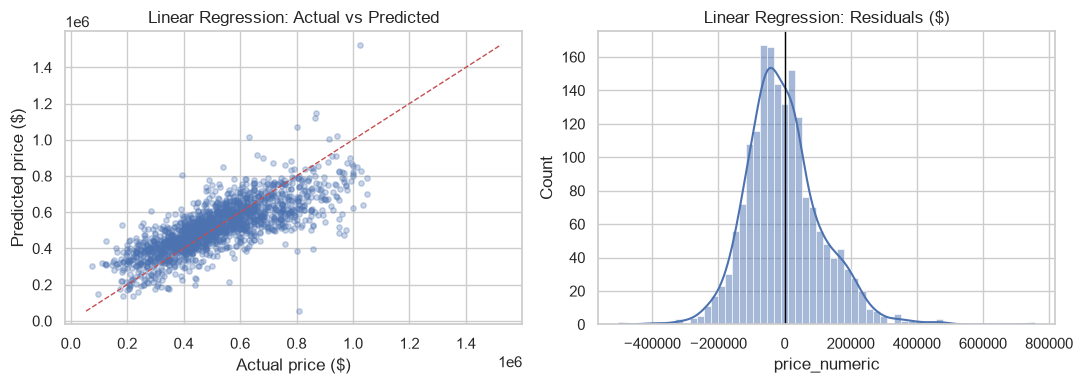

Random Forest: RMSE=$96,565  MAE=$72,361  R2=0.710  MAPE=15.0%


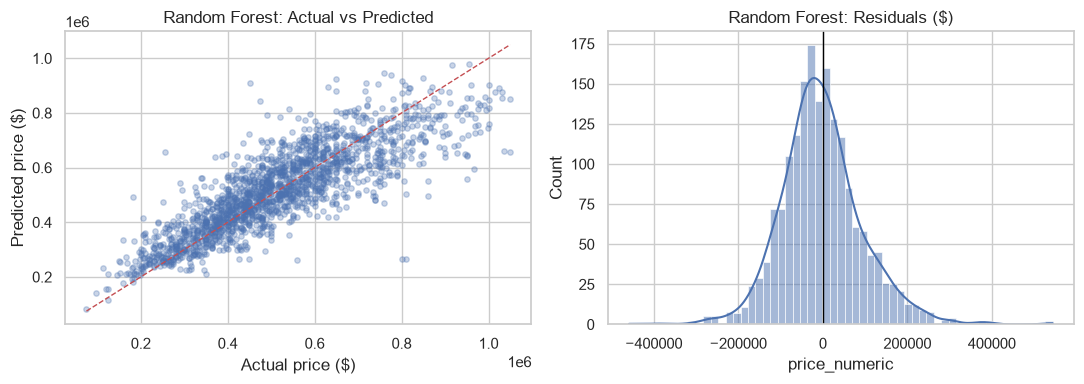

XGBoost: RMSE=$94,481  MAE=$71,902  R2=0.723  MAPE=15.3%


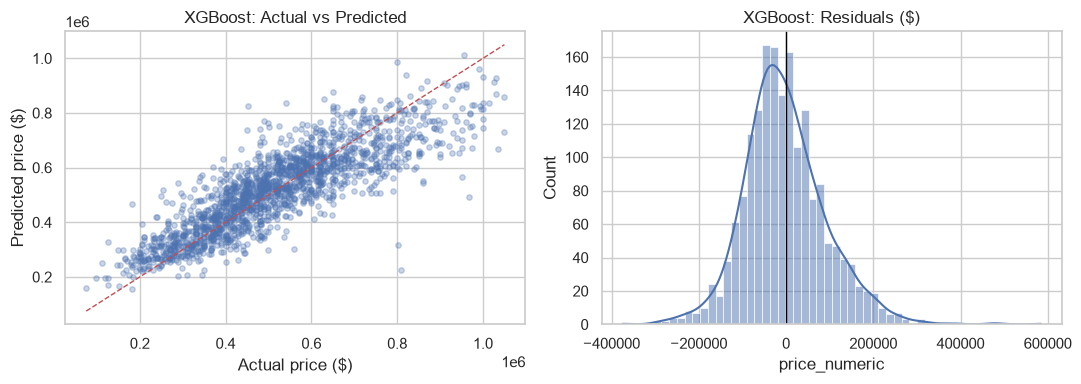

In [80]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

results = []
fitted_pipelines = {}
for name, model in models.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    result = train_and_evaluate(pipeline, name, X_train, y_train, X_test, y_test)
    results.append(result)
    fitted_pipelines[name] = result["pipeline"]

## 10. Model Comparison

,model,rmse,mae,r2,mape
2,XGBoost,94480.786932,71902.281887,0.722628,15.282388
1,Random Forest,96564.888933,72361.472953,0.710256,14.979674
0,Linear Regression,114475.230591,87293.838201,0.592809,19.530631


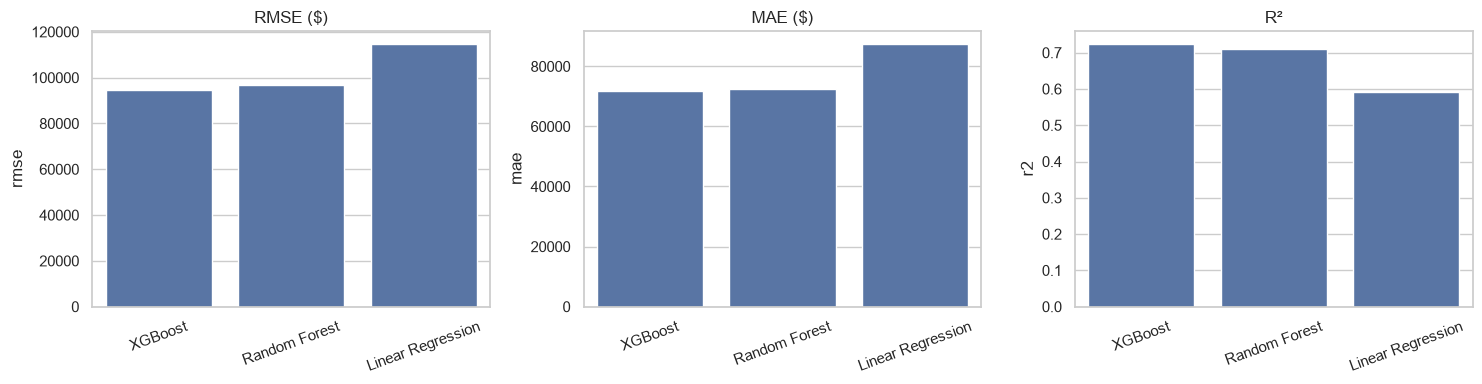

Best model by RMSE: XGBoost


In [83]:
results_df = pd.DataFrame(results)[["model", "rmse", "mae", "r2", "mape"]].sort_values("rmse")
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, label in zip(axes, ["rmse", "mae", "r2"], ["RMSE ($)", "MAE ($)", "R\u00b2"]):
    sns.barplot(data=results_df, x="model", y=metric, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["model"]
print(f"Best model by RMSE: {best_model_name}")

## 11. Feature Importance & Interpretation

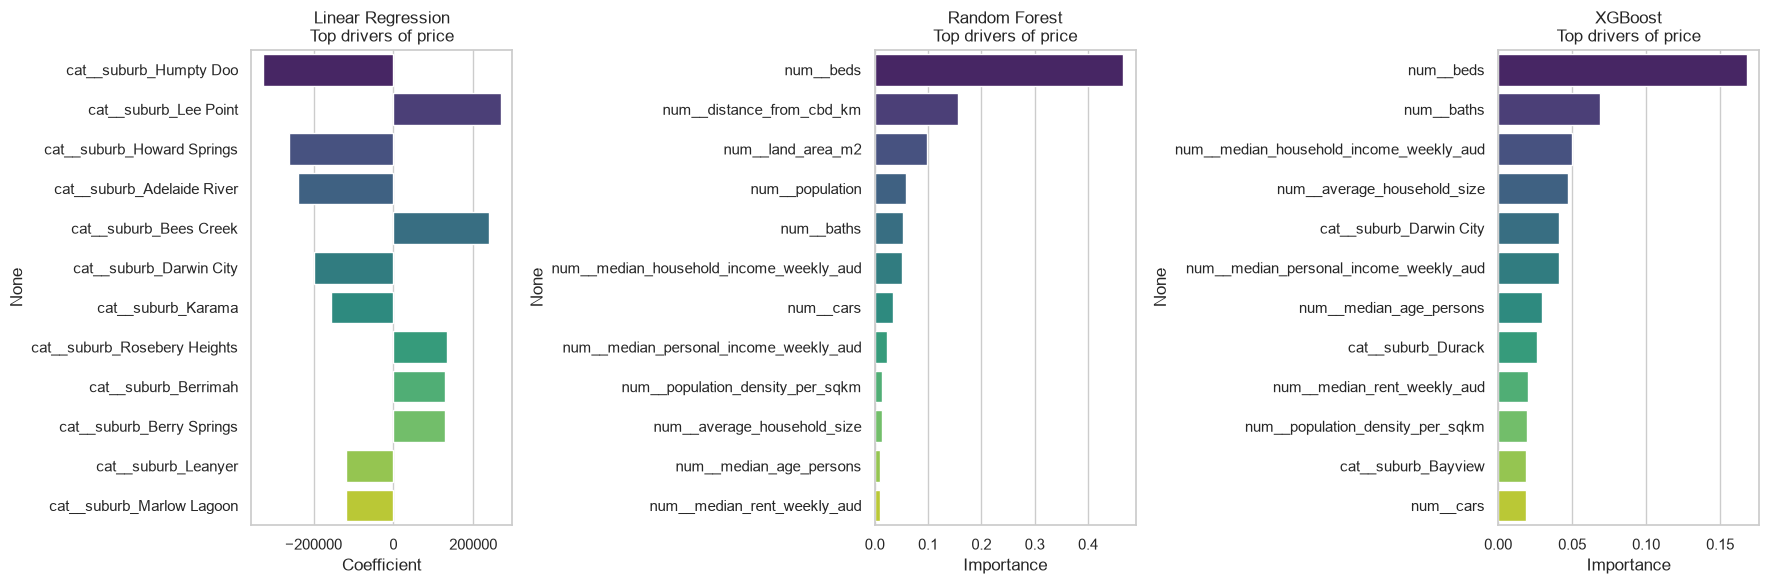

In [84]:
best_pipeline = fitted_pipelines[best_model_name]
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, ["Linear Regression", "Random Forest", "XGBoost"]):
    pipe = fitted_pipelines[name]
    model = pipe.named_steps["model"]
    names = pipe.named_steps["preprocess"].get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        importance = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False).head(12)
        label = "Importance"
    else:
        importance = pd.Series(model.coef_, index=names).sort_values(key=abs, ascending=False).head(12)
        label = "Coefficient"

    sns.barplot(x=importance.values, y=importance.index, ax=ax, palette="viridis")
    ax.set_title(f"{name}\nTop drivers of price")
    ax.set_xlabel(label)

plt.tight_layout()
plt.show()